<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L3_Beyond_Captioning_VQA_and_Dialog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=bxYkGKSCTlA) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P03.pdf)

In [1]:
# Week 8, Lecture 3: Beyond Captioning : VQA and Dialog
from IPython.display import HTML, display

VIDEO_ID = "bxYkGKSCTlA"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 3: Beyond Captioning: Visual QA and Visual Dialog

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.3 Visual QA and Dialog**.

Captioning lets the model choose what to say about a picture. This lecture pins the topic down with a
question, and then with a whole conversation. The notebook builds a small synthetic VQA dataset, trains
the four families of VQA model the slides survey on the same frozen image features, then turns the same
scenes into dialogs and implements the Visual Dialog encoders, decoders and ranking protocol from scratch.

**What you will learn**
- The **VQA** task and the four datasets on the slides (VQA, COCO-QA, Visual7W, CLEVR), with their numbers.
- Two simple baselines: **LSTM + image** with an element-wise product, and **iBOWIMG** with a bag of words and concatenation, and why a full bilinear fusion is unaffordable.
- **Stacked Attention Networks**: $h_A = \tanh(W_I v_I \oplus W_Q u)$, $p_I = \mathrm{softmax}(W_P h_A)$, $\tilde v = \sum_i p_i v_i$, and the additive refinement $u' = \tilde v + u$ that is meant to let a second layer narrow the focus (we measure whether it does).
- **Hierarchical co-attention**: word, phrase and question levels, and the parallel co-attention affinity $C = \tanh(Q^\top W_b V)$ that attends to the question as well as the image.
- **Visual Dialog**: image, history and a follow-up question, and why the task is evaluated by **ranking 100 candidate answers** (mean rank, mean reciprocal rank, recall at $k$) instead of BLEU.
- The three history encoders (**late fusion**, **hierarchical recurrent**, **memory network**) and the two decoders (**generative** log-likelihood, **discriminative** softmax over options), trained and compared on the same dialogs.

**Contents**

1. The VQA task and its datasets
2. A synthetic VQA dataset
3. Two simple baselines: LSTM + image and iBOWIMG
4. Stacked Attention Networks
5. Hierarchical co-attention
6. Accuracy by question type
7. Visual Dialog: the task and a synthetic dialog
8. Evaluating Visual Dialog by ranking
9. Encoders and decoders for Visual Dialog
10. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU
needed). No dataset is downloaded: the scenes, questions and dialogs are generated in the notebook. Run
the setup cell first, then go top to bottom.

## Review

The previous lecture generated a caption from an image: a CNN encoder, an LSTM decoder, and soft or hard
attention over a grid of annotation vectors so that each word could look at a different part of the
picture. The deck opens by asking whether the opposite direction, caption to image, is possible, and
answers that deep generative models can do it, which is where the course goes in later weeks. This
lecture stays on the understanding side but makes the output specific: instead of saying *something*
about the picture, the model has to answer a **question** about it, and then a **sequence of questions**
in a dialog. That changes the architecture (the question has to be fused with the image, and the
history has to be remembered) and, as it turns out, changes what it means to evaluate the system.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100
print('torch', torch.__version__, '| device:', device)

def count_params(m):
    """Number of trainable parameters in a module."""
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def show_scene(ax, img, title=None, fontsize=8):
    """img: (3,H,W) tensor or (H,W,3) array in [0,1]."""
    if torch.is_tensor(img):
        img = img.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] == 3:
            img = img.transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0, 1), interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=fontsize)

torch 2.8.0 | device: cpu


## 1. The VQA task and its datasets

**Visual Question Answering** (Agrawal et al., IJCV 2015): given an image and a free-form natural
language question about it, produce a natural language answer. The slides show the CloudCV demo where you
can type any question about any photo; the questions people ask are short ("what color is the bus", "how
many people are there", "is the man wearing a hat"), and the answers are shorter (a colour, a number, a
noun, yes or no). That is why almost every VQA model treats answering as **classification over the most
frequent answers** (typically the top 1000), even though the task is nominally open-ended.

The slides survey four datasets. Their numbers are worth keeping in mind because they decide what a model
can learn:

| Dataset | Scale | What is notable |
|---|---|---|
| **VQA** (Agrawal et al., IJCV 2015) | 250K images (MS COCO plus 50K abstract scenes), 750K questions, 10M answers | Open-ended and multiple-choice answers; every question answered by 10 human annotators who saw the image, plus 3 who did not |
| **COCO-QA** (Ren et al., NeurIPS 2015) | 118K QA pairs on 123K images | Generated **automatically from COCO captions**; exactly 4 question types: *what object, how many, what color, where* |
| **Visual7W** (Zhu et al., CVPR 2016) | 328K QA pairs on about 47K images | The seven W's: *what, where, when, who, why, how, which*; two task types, **telling** (text answer) and **pointing** (choose a box) |
| **CLEVR** (Johnson et al., CVPR 2017) | 100K rendered images, 1M automatically generated questions | Synthetic scenes of simple shapes; questions are compositional and **require reasoning** (counting, comparing, spatial relations) |

Two of these are relevant to what we build below. COCO-QA shows that a **templated, automatically
generated** question set with a handful of types is a legitimate benchmark, and CLEVR shows that
**rendered scenes of coloured shapes** are enough to test whether a model can count, compare and reason
about spatial relations. Our synthetic dataset borrows both ideas at a tiny scale.

The slide's numbers are worth checking rather than copying. At first sight the VQA row does not multiply
out (750K questions times 10 annotators is 7.5M, not 10M), but the slide reproduces the paper's own
figures, and the paper's answer count also includes 3 answers per question collected from workers who
did **not** see the image, as a language-only baseline. The cell below reconciles the row.

In [3]:
# The dataset arithmetic. The VQA row reconciles once the paper's answer count is unpacked.
vqa_q = 764_163                        # the paper's question count (the slide rounds it to 750K)
ann_with_img, ann_without_img = 10, 3  # answers per question collected with, and without, the image
grounded = vqa_q * ann_with_img
blind = vqa_q * ann_without_img
total = grounded + blind

print(f'  VQA: {vqa_q:,} questions x {ann_with_img} annotators who saw the image = {grounded:,} ({grounded / 1e6:.1f}M) answers')
print(f'       plus {vqa_q:,} x {ann_without_img} answers collected without the image = {blind:,}')
print(f'       total {total:,} = {total / 1e6:.2f}M, which the slide rounds to 10M')
assert round(vqa_q * (ann_with_img + ann_without_img) / 1e6) == 10, 'the paper total should round to the slide 10M'

print(f'\n  Visual7W: 328,000 / 47,000 images = {328_000 / 47_000:.1f} QA pairs per image')
print(f'  CLEVR   : 1,000,000 / 100,000 images = {1_000_000 // 100_000} questions per image')
print(f'  COCO-QA : 118,000 QA pairs on 123,000 COCO images, i.e. {118/123:.2f} per image; COCO-QA')
print(f'            generates one question per caption and filters aggressively, so the 118K pairs')
print(f'            are fewer than the 123K COCO images they were generated from')

  VQA: 764,163 questions x 10 annotators who saw the image = 7,641,630 (7.6M) answers
       plus 764,163 x 3 answers collected without the image = 2,292,489
       total 9,934,119 = 9.93M, which the slide rounds to 10M

  Visual7W: 328,000 / 47,000 images = 7.0 QA pairs per image
  CLEVR   : 1,000,000 / 100,000 images = 10 questions per image
  COCO-QA : 118,000 QA pairs on 123,000 COCO images, i.e. 0.96 per image; COCO-QA
            generates one question per caption and filters aggressively, so the 118K pairs
            are fewer than the 123K COCO images they were generated from


## 2. A synthetic VQA dataset

Real VQA needs a pretrained CNN, word vectors and hours of training. To see the models work in seconds we
generate a dataset in the spirit of CLEVR and COCO-QA:

- **Scenes**: 32 x 32 RGB images with a 3 x 3 grid of cells. Each scene has 2 to 4 objects, one per cell,
  each a random **shape** (square, circle, triangle) in a random **colour** (red, green, blue, yellow),
  with a little jitter in position, size and colour so that nothing is pixel-identical.
- **Questions** of four types, from templates, exactly as COCO-QA has four types:
  - **count**: "how many red objects are there", "how many circles are there", "how many objects are there";
  - **colour**: "what color is the circle" (only asked when the scene has exactly one circle);
  - **shape**: "what shape is the blue object" (only when exactly one object is blue);
  - **spatial**: "what color is the object left of the red circle", "what shape is above the green square"
    (the referent is unique; the answer is a colour or shape, or *nothing* if that cell is empty).
- **Answers** are one of 13 classes: the numbers 0 to 4, the four colours, the three shapes, and *nothing*.

A question is asked only when it has a single correct answer, so the labels are exact. Every question is
tokenised with a fixed vocabulary; the same vocabulary serves the dialogs later.

In [4]:
COLORS = ['red', 'green', 'blue', 'yellow']
SHAPES = ['square', 'circle', 'triangle']
RGB = {'red': (0.85, 0.15, 0.15), 'green': (0.15, 0.70, 0.20),
       'blue': (0.20, 0.35, 0.90), 'yellow': (0.92, 0.82, 0.10)}
ROWS, COLS = ['top', 'middle', 'bottom'], ['left', 'center', 'right']
REL = {'left of': (0, -1), 'right of': (0, 1), 'above': (-1, 0), 'below': (1, 0)}
IMG, CELL, MARGIN = 32, 10, 1                 # 3 cells of 10 px plus a 1 px border
_YS, _XS = np.mgrid[0:IMG, 0:IMG]

def shape_mask(shape, cx, cy, r):
    """Boolean pixel mask of a shape centred at (cx, cy) with radius r."""
    if shape == 'square':
        return (np.abs(_XS - cx) <= r) & (np.abs(_YS - cy) <= r)
    if shape == 'circle':
        return (_XS - cx) ** 2 + (_YS - cy) ** 2 <= r * r
    t = (_YS - (cy - r)) / (2.0 * r)              # triangle: apex at the top
    return (_YS >= cy - r) & (_YS <= cy + r) & (np.abs(_XS - cx) <= r * t)

def make_scene(rng):
    """Returns an (H, W, 3) image in [0, 1] and a list of objects dict(color, shape, row, col)."""
    img = np.full((IMG, IMG, 3), 0.90, np.float32) + rng.normal(0, 0.02, (IMG, IMG, 3)).astype(np.float32)
    n = int(rng.integers(2, 5))
    objs = []
    for cell in rng.choice(9, size=n, replace=False):
        row, col = divmod(int(cell), 3)
        color, shape = COLORS[rng.integers(4)], SHAPES[rng.integers(3)]
        cx = MARGIN + col * CELL + CELL / 2 + rng.uniform(-1, 1)
        cy = MARGIN + row * CELL + CELL / 2 + rng.uniform(-1, 1)
        m = shape_mask(shape, cx, cy, rng.uniform(2.6, 3.8))
        img[m] = np.clip(np.array(RGB[color]) + rng.uniform(-0.08, 0.08, 3), 0, 1).astype(np.float32)
        objs.append(dict(color=color, shape=shape, row=row, col=col))
    return np.clip(img, 0, 1), objs

def neighbour(objs, o, rel):
    """The object in the cell `rel` (left of / right of / above / below) object o, or None."""
    dr, dc = REL[rel]
    for p in objs:
        if p['row'] == o['row'] + dr and p['col'] == o['col'] + dc:
            return p
    return None

def unique_by(objs, key):
    """Objects whose value of `key` (color or shape) appears exactly once in the scene."""
    cnt = Counter(o[key] for o in objs)
    return [o for o in objs if cnt[o[key]] == 1]

def unique_pairs(objs):
    """Objects whose (color, shape) pair is unique in the scene."""
    cnt = Counter((o['color'], o['shape']) for o in objs)
    return [o for o in objs if cnt[(o['color'], o['shape'])] == 1]

def pick(rng, seq):
    return seq[int(rng.integers(len(seq)))]

def vqa_questions(objs, rng):
    """One question per type where the scene allows it: list of (type, question, answer)."""
    qs = []
    form = int(rng.integers(3))                                    # count
    if form == 0:
        present = sorted({o['color'] for o in objs})
        c = pick(rng, present) if rng.random() < 0.7 else pick(rng, COLORS)
        qs.append(('count', f'how many {c} objects are there', str(sum(o['color'] == c for o in objs))))
    elif form == 1:
        present = sorted({o['shape'] for o in objs})
        s = pick(rng, present) if rng.random() < 0.7 else pick(rng, SHAPES)
        qs.append(('count', f'how many {s}s are there', str(sum(o['shape'] == s for o in objs))))
    else:
        qs.append(('count', 'how many objects are there', str(len(objs))))
    u = unique_by(objs, 'shape')                                   # colour
    if u:
        o = pick(rng, u); qs.append(('color', f'what color is the {o["shape"]}', o['color']))
    u = unique_by(objs, 'color')                                   # shape
    if u:
        o = pick(rng, u); qs.append(('shape', f'what shape is the {o["color"]} object', o['shape']))
    u = unique_pairs(objs)                                         # spatial relation
    if u:
        o = pick(rng, u)
        with_nb = [r for r in REL if neighbour(objs, o, r) is not None]
        rel = pick(rng, with_nb) if (with_nb and rng.random() < 0.8) else pick(rng, list(REL))
        nb = neighbour(objs, o, rel)
        if rng.random() < 0.5:
            qs.append(('spatial', f'what color is the object {rel} the {o["color"]} {o["shape"]}',
                       nb['color'] if nb else 'nothing'))
        else:
            qs.append(('spatial', f'what shape is {rel} the {o["color"]} {o["shape"]}',
                       nb['shape'] if nb else 'nothing'))
    return qs

# --- vocabulary and tokeniser (shared with the dialogs of Section 7) ---
WORDS = ['<pad>', '<bos>', '<eos>', 'how', 'many', 'objects', 'object', 'are', 'there', 'what', 'color',
         'is', 'the', 'shape', 'left', 'right', 'of', 'above', 'below', 'it', 'where', 'a', 'no', 'one',
         'two', 'three', 'four', 'top', 'middle', 'bottom', 'center', 'nothing'] \
        + COLORS + SHAPES + [s + 's' for s in SHAPES]
W2I = {w: i for i, w in enumerate(WORDS)}
PAD, BOS, EOS = 0, 1, 2
QTYPES = ['count', 'color', 'shape', 'spatial']
ANSWERS = ['0', '1', '2', '3', '4'] + COLORS + SHAPES + ['nothing']
A2I = {a: i for i, a in enumerate(ANSWERS)}
L_Q = 10                                                          # longest question has 10 words

def tokenize(s, L, bos_eos=False):
    """Words -> ids, right-padded with PAD to length L (optionally wrapped in BOS ... EOS)."""
    ids = [W2I[w] for w in s.split()]
    if bos_eos:
        ids = [BOS] + ids + [EOS]
    assert len(ids) <= L, s
    return ids + [PAD] * (L - len(ids))

def detokenize(ids):
    return ' '.join(WORDS[i] for i in ids if i not in (PAD, BOS, EOS))

def build_vqa(n_scenes, seed):
    """Generate scenes and questions; return a dict of tensors plus the raw strings."""
    rng = np.random.default_rng(seed)
    imgs, objs_all, rows = [], [], []
    for i in range(n_scenes):
        img, objs = make_scene(rng)
        imgs.append(img); objs_all.append(objs)
        rows += [(i, t, q, a) for (t, q, a) in vqa_questions(objs, rng)]
    images = torch.from_numpy(np.stack(imgs)).permute(0, 3, 1, 2).contiguous()
    return dict(images=images, objs=objs_all,
                scene=torch.tensor([r[0] for r in rows]),
                qtype=torch.tensor([QTYPES.index(r[1]) for r in rows]),
                qtok=torch.tensor([tokenize(r[2], L_Q) for r in rows]),
                ans=torch.tensor([A2I[r[3]] for r in rows]),
                questions=[r[2] for r in rows], answers=[r[3] for r in rows])

t0 = time.perf_counter()
vqa_tr = build_vqa(4000, seed=1)
vqa_te = build_vqa(400, seed=2)
print(f'generated in {time.perf_counter() - t0:.1f} s')
print(f'train: {tuple(vqa_tr["images"].shape)} images, {len(vqa_tr["ans"])} questions | '
      f'test: {tuple(vqa_te["images"].shape)} images, {len(vqa_te["ans"])} questions')
print(f'vocabulary: {len(WORDS)} words | answer classes: {len(ANSWERS)}')

# The tokeniser round-trips every question exactly.
for q in vqa_tr['questions'][:2000]:
    assert detokenize(tokenize(q, L_Q)) == q
print('tokenize -> detokenize round-trips 2000 questions exactly. OK')

print('\nquestions per type (train):', {t: int((vqa_tr['qtype'] == i).sum()) for i, t in enumerate(QTYPES)})
print('answer histogram (train):  ', {a: int((vqa_tr['ans'] == i).sum()) for i, a in enumerate(ANSWERS)})

generated in 0.4 s
train: (4000, 3, 32, 32) images, 14265 questions | test: (400, 3, 32, 32) images, 1443 questions
vocabulary: 42 words | answer classes: 13
tokenize -> detokenize round-trips 2000 questions exactly. OK

questions per type (train): {'count': 4000, 'color': 3036, 'shape': 3377, 'spatial': 3852}
answer histogram (train):   {'0': 273, '1': 1456, '2': 1182, '3': 625, '4': 464, 'red': 970, 'green': 1025, 'blue': 991, 'yellow': 987, 'square': 1392, 'circle': 1414, 'triangle': 1464, 'nothing': 2022}


A few scenes with one of their questions each. The labels are exact by construction, which is the
whole reason to use a synthetic set: when a model gets a spatial question wrong, it is the model.

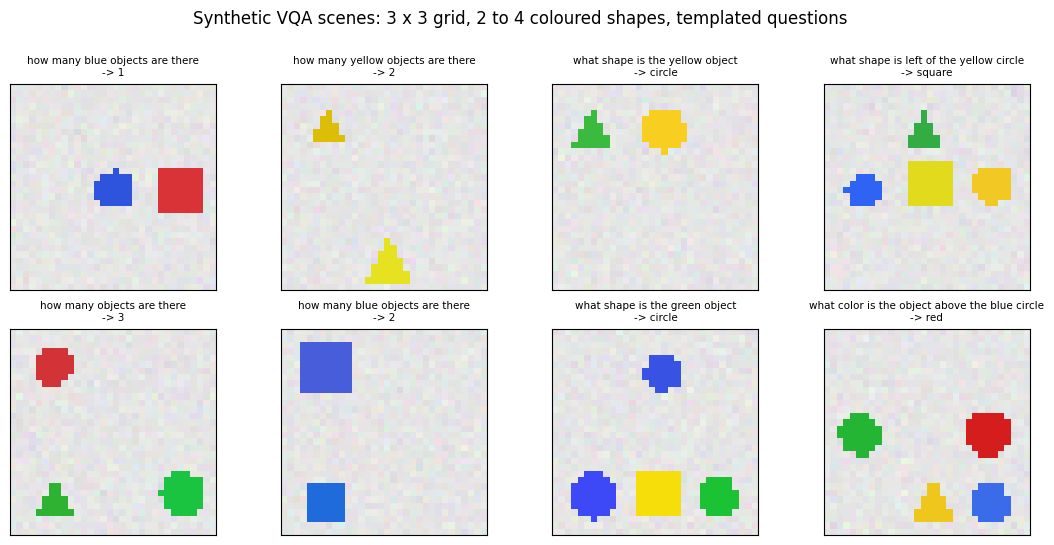

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5.4))
shown = 0
for ax in axes.flat:
    rows = (vqa_tr['scene'] == shown).nonzero().flatten().tolist()
    k = rows[shown % len(rows)]
    show_scene(ax, vqa_tr['images'][shown],
               f'{vqa_tr["questions"][k]}\n-> {vqa_tr["answers"][k]}', fontsize=7.5)
    shown += 1
fig.suptitle('Synthetic VQA scenes: 3 x 3 grid, 2 to 4 coloured shapes, templated questions', y=1.0)
plt.tight_layout(); plt.show()

### Widget 1: browse the dataset

Drag `scene` through the training set. Every question generated for that scene is listed with its
answer; the four types appear only when the scene admits them (a colour question needs a unique shape,
a spatial question a unique colour-shape pair). Look for scenes where the *nothing* answer arises
because the relation points off the grid.

In [6]:
def browse_scene(scene=0):
    rows = (vqa_tr['scene'] == scene).nonzero().flatten().tolist()
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    show_scene(ax, vqa_tr['images'][scene], f'train scene {scene}: {len(vqa_tr["objs"][scene])} objects')
    plt.tight_layout(); plt.show()
    for k in rows:
        print(f'  [{QTYPES[int(vqa_tr["qtype"][k])]:7s}] {vqa_tr["questions"][k]:52s} -> {vqa_tr["answers"][k]}')

interact(browse_scene, scene=IntSlider(min=0, max=99, step=1, value=0, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='scene', max=99), Output()), _do…

## 3. Two simple baselines: LSTM + image and iBOWIMG

Every VQA model has to combine an image vector with a question vector. The slides show two baselines
that differ in how they encode the question and how they fuse.

**LSTM + image** (the baseline in Agrawal et al.): the image goes through VGG, the last hidden layer
(4096-d) is L2-normalised and projected to 1024; the question goes through a 2-layer LSTM whose final
hidden and cell states (2 x 2 x 512 = 2048 numbers) are projected to 1024; the two are combined by an
**element-wise product** and a softmax over the 1000 most frequent answers.

**iBOWIMG** (Zhou et al., arXiv 2015, "Simple baseline for VQA"): the question is a **bag of words**
(the sum, or count-weighted sum, of word embeddings, so word order is ignored), the image is a GoogLeNet
feature, the two are **concatenated**, and one linear layer plus a softmax gives the answer. It is
embarrassingly simple and was competitive when published.

A third option, a **full bilinear** interaction $z_k = v^\top W_k q$ that lets every image dimension talk
to every question dimension, is the natural generalisation. Counting its parameters shows why nobody uses
it naively.

In [7]:
# Three fusion strategies, and what each costs.
d_v, d_q, n_ans = 1024, 1024, 1000

img = torch.randn(4, d_v)
que = torch.randn(4, d_q)

# 1. Element-wise product: shape-preserving, then one linear layer.
fused_prod = img * que
head_prod = nn.Linear(d_v, n_ans)
p_prod = sum(p.numel() for p in head_prod.parameters())

# 2. Concatenation: doubles the width, then one linear layer.
fused_cat = torch.cat([img, que], dim=1)
head_cat = nn.Linear(d_v + d_q, n_ans)
p_cat = sum(p.numel() for p in head_cat.parameters())

# 3. Full bilinear: a weight per (image dim, question dim, answer) triple.
p_bilinear = d_v * d_q * n_ans

assert fused_prod.shape == (4, d_v)
assert fused_cat.shape == (4, d_v + d_q)

print(f'  element-wise product : fused {tuple(fused_prod.shape)}  head {p_prod:>13,} params')
print(f'  concatenation        : fused {tuple(fused_cat.shape)}  head {p_cat:>13,} params')
print(f'  full bilinear        : ---                head {p_bilinear:>13,} params')
print(f'\n  bilinear costs {p_bilinear / p_prod:,.0f}x the element-wise product.')
print('  That blow-up is exactly why compact/factorised bilinear pooling was invented.')

# Cost scaling with the feature width, and a property of the product that concatenation lacks.
print('\n  cost of each fusion as the feature width grows:')
print(f'    {"d":>6s} {"product":>12s} {"concat":>12s} {"bilinear":>16s}')
for d_ in (128, 256, 512, 1024):
    prod, cat, bil = d_ * n_ans + n_ans, 2 * d_ * n_ans + n_ans, d_ * d_ * n_ans
    assert cat > prod and bil > cat
    print(f'    {d_:6d} {prod:12,} {cat:12,} {bil:16,}')
a_, b_ = torch.randn(64), torch.randn(64)
assert torch.allclose(a_ * b_, b_ * a_), 'product should be symmetric'
assert not torch.allclose(torch.cat([a_, b_]), torch.cat([b_, a_])), 'concat should not be'
print('\n  element-wise product is symmetric: swapping image and question changes nothing;')
print('  concatenation is not, so a linear head can treat the two modalities differently.')

  element-wise product : fused (4, 1024)  head     1,025,000 params
  concatenation        : fused (4, 2048)  head     2,049,000 params
  full bilinear        : ---                head 1,048,576,000 params

  bilinear costs 1,023x the element-wise product.
  That blow-up is exactly why compact/factorised bilinear pooling was invented.

  cost of each fusion as the feature width grows:
         d      product       concat         bilinear
       128      129,000      257,000       16,384,000
       256      257,000      513,000       65,536,000
       512      513,000    1,025,000      262,144,000
      1024    1,025,000    2,049,000    1,048,576,000

  element-wise product is symmetric: swapping image and question changes nothing;
  concatenation is not, so a linear head can treat the two modalities differently.


In [8]:
# The baseline architecture from the slides, as a shape trace at the paper's sizes.
class VQABaseline(nn.Module):
    """CNN 4096 -> 1024, LSTM 2x2x512 -> 1024, point-wise product, softmax over 1000."""
    def __init__(self, n_ans=1000):
        super().__init__()
        self.img_fc = nn.Linear(4096, 1024)          # VGG last hidden layer, L2-normalised
        self.q_fc = nn.Linear(2 * 2 * 512, 1024)     # 2 layers x {h, c} x 512 units
        self.classifier = nn.Linear(1024, n_ans)

    def forward(self, img_feat, q_state):
        v = torch.tanh(self.img_fc(F.normalize(img_feat, dim=1)))
        q = torch.tanh(self.q_fc(q_state))
        return self.classifier(v * q)                # point-wise multiplication

model = VQABaseline()
logits = model(torch.randn(2, 4096), torch.randn(2, 2048))
probs = torch.softmax(logits, dim=1)

assert logits.shape == (2, 1000)
assert torch.allclose(probs.sum(1), torch.ones(2), atol=1e-5)
print(f'  image 4096 -> 1024, question 2x2x512 = {2*2*512} -> 1024')
print(f'  fused 1024 -> {logits.shape[1]} answers, softmax rows sum to {probs.sum(1)[0]:.4f}')
print(f'  total parameters: {sum(p.numel() for p in model.parameters()):,}')

  image 4096 -> 1024, question 2x2x512 = 2048 -> 1024
  fused 1024 -> 1000 answers, softmax rows sum to 1.0000
  total parameters: 7,318,504


### 3.a The pieces our small models share

Every VQA model on the slides takes its image features from a CNN **pretrained on another task and then
frozen**: VGG or GoogLeNet trained on ImageNet. Nothing is pretrained on shapes on grey backgrounds, so we
do the analogous thing at our scale: a three-layer CNN with batch normalisation is trained once to name
the object in each cell of the 3 x 3 grid (a tiny detector), then frozen, and its **8 x 8 grid of 32-d
region vectors** (64 regions) is computed once for every scene. The global vector for the baselines is
the **mean over regions** (the analogue of VGG's fc7 vector, which has no spatial layout), and the grid
itself is what the attention models of Sections 4 and 5 attend over. All four models then train on
exactly the same features, so the comparison in Section 6 is about the fusion, not the CNN.

One detail matters for spatial questions. A frozen feature says *what* is in a region, not *where* the
region is, so we append the region's normalised $(y, x)$ coordinates to every region vector, as later
VQA models built on bottom-up attention features (Anderson et al., CVPR 2018, in the slide's reading
list) append the normalised box coordinates of each region. The LSTMs run over the padded question and the state at the last real word is read off, so
no sequence packing is needed.

The **bag of words** is written from scratch as a count vector times the embedding matrix,
$q = \sum_{w \in \text{question}} E_w = c^\top E$ with $c$ the word-count vector, and checked against
`nn.EmbeddingBag(mode='sum')`, which is the idiomatic implementation of exactly this sum.

In [9]:
D = 32          # region feature width
H = 64          # hidden width of every small model
V = len(WORDS)

class SceneCNN(nn.Module):
    """32x32 image -> (N, 64 regions, D): the v_I of the attention models."""
    def __init__(self, d=D):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),    # 32 -> 16
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 16 -> 8
            nn.Conv2d(32, d, 3, padding=1), nn.BatchNorm2d(d), nn.ReLU())
    def forward(self, x):
        f = self.net(x)                                     # (N, D, 8, 8)
        return f.flatten(2).transpose(1, 2)                 # (N, 64, D), row-major over the 8x8 grid

def bag_of_words(tok, E):
    """From scratch: count each word (ignoring PAD), then counts @ embedding matrix."""
    counts = F.one_hot(tok, E.shape[0]).sum(1).float()      # (N, V) word counts
    counts[:, PAD] = 0
    return counts @ E                                       # (N, d)

class BOW(nn.Module):
    def __init__(self, d=H):
        super().__init__()
        self.emb = nn.Embedding(V, d, padding_idx=PAD)
    def forward(self, tok):
        return bag_of_words(tok, self.emb.weight)

class QuestionLSTM(nn.Module):
    """Embedding + LSTM over the padded question; returns (per-word outputs, final hidden)."""
    def __init__(self, d=H, emb=None):
        super().__init__()
        self.emb = emb if emb is not None else nn.Embedding(V, d, padding_idx=PAD)
        self.lstm = nn.LSTM(d, d, batch_first=True)
    def forward(self, tok):
        lengths = (tok != PAD).sum(1).clamp(min=1)
        out, _ = self.lstm(self.emb(tok))                                  # (N, T, d), run over the padding too
        last = out[torch.arange(tok.shape[0], device=tok.device), lengths - 1]   # state at the last real word
        return out, last

# Check the from-scratch bag of words against nn.EmbeddingBag on real questions.
bow = BOW().to(device)
bag = nn.EmbeddingBag(V, H, mode='sum', padding_idx=PAD).to(device)
bag.weight = bow.emb.weight                                # share the embedding matrix
tok = vqa_tr['qtok'][:256].to(device)
mine, ref = bow(tok), bag(tok)
assert torch.allclose(mine, ref, atol=1e-5)
print(f'bag_of_words matches nn.EmbeddingBag(mode="sum") on 256 questions (max diff {(mine - ref).abs().max():.1e}). OK')
cnn = SceneCNN().to(device)
print('SceneCNN:', tuple(cnn(vqa_tr['images'][:2].to(device)).shape), '= (N, regions, D) |',
      f'{count_params(cnn):,} params')

bag_of_words matches nn.EmbeddingBag(mode="sum") on 256 questions (max diff 9.5e-07). OK
SceneCNN: (2, 64, 32) = (N, regions, D) | 14,496 params


The pretraining task is a 13-way classification per cell (empty, or one of 4 colours x 3 shapes), read off
the 8 x 8 map through a 1 x 1 convolution and an average over the map positions that fall inside each
cell (a fixed 3 x 8 pooling matrix built from the grid geometry). It takes a few seconds and reaches
almost perfect cell accuracy, after which the CNN is never updated again.

In [10]:
# Data on the device, indexed per question.
IM_TR, IM_TE = vqa_tr['images'].to(device), vqa_te['images'].to(device)
TR = {k: vqa_tr[k].to(device) for k in ('scene', 'qtok', 'ans', 'qtype')}
TE = {k: vqa_te[k].to(device) for k in ('scene', 'qtok', 'ans', 'qtype')}

def cell_labels(objs_all):
    """(N, 3, 3) class per grid cell: 0 = empty, else 1 + 3 * colour + shape."""
    lab = torch.zeros(len(objs_all), 3, 3, dtype=torch.long)
    for n, objs in enumerate(objs_all):
        for o in objs:
            lab[n, o['row'], o['col']] = 1 + COLORS.index(o['color']) * len(SHAPES) + SHAPES.index(o['shape'])
    return lab

LAB_TR, LAB_TE = cell_labels(vqa_tr['objs']).to(device), cell_labels(vqa_te['objs']).to(device)
N_CELL = 1 + len(COLORS) * len(SHAPES)

# Pooling matrix from the geometry: POOL[c, p] = fraction of the 4 pixels of map position p that lie in cell c.
_cell_of_px = ((torch.arange(IMG) - MARGIN) // CELL).clamp(0, 2)              # pixel -> cell (borders join the nearest)
POOL = torch.zeros(3, 8)
for p in range(8):
    for px in range(4 * p, 4 * p + 4):
        POOL[_cell_of_px[px], p] += 0.25
POOL = (POOL / POOL.sum(1, keepdim=True)).to(device)                          # rows average over one cell each

class CellDetector(nn.Module):
    """SceneCNN + 1x1 conv head, averaged over the map positions of each 3 x 3 cell: which object sits there?"""
    def __init__(self):
        super().__init__()
        self.cnn, self.head = SceneCNN(), nn.Conv2d(D, N_CELL, 1)
    def forward(self, img):
        logits = self.head(self.cnn.net(img))                                  # (N, 13, 8, 8)
        return torch.einsum('ri,ncij,sj->ncrs', POOL, logits, POOL)            # (N, 13, 3, 3)

set_seed(0)
det = CellDetector().to(device)
opt = torch.optim.Adam(det.parameters(), lr=3e-3)
DET_STEPS = 300
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: 1 - s / DET_STEPS)
g = torch.Generator().manual_seed(0)
t0 = time.perf_counter()
for s in range(DET_STEPS):
    idx = torch.randint(0, len(IM_TR), (128,), generator=g).to(device)
    loss = F.cross_entropy(det(IM_TR[idx]), LAB_TR[idx])
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    if s % 100 == 0 or s == DET_STEPS - 1:
        print(f'  detector step {s:3d} | loss {loss.item():.3f}')
det.eval()                                                   # frozen from here on: BN uses its running statistics
with torch.no_grad():
    cell_acc = (det(IM_TE).argmax(1) == LAB_TE).float().mean().item()
    grid_tr, grid_te = det.cnn(IM_TR), det.cnn(IM_TE)       # (N, 64, D) region grids, computed once
for p in det.parameters():
    p.requires_grad_(False)
assert cell_acc > 0.95, 'the detector should name almost every cell correctly'
print(f'  pretrained in {time.perf_counter() - t0:.1f} s | test cell accuracy {cell_acc:.3f}')

# Append the normalised (y, x) coordinate of every region, as models on bottom-up features append box coordinates.
yy, xx = torch.meshgrid(torch.linspace(-1, 1, 8), torch.linspace(-1, 1, 8), indexing='ij')
COORDS = torch.stack([yy.flatten(), xx.flatten()], 1).to(device)           # (64, 2), row-major like the grid
FEAT_TR = torch.cat([grid_tr, COORDS[None].expand(len(grid_tr), -1, -1)], 2)
FEAT_TE = torch.cat([grid_te, COORDS[None].expand(len(grid_te), -1, -1)], 2)
D_F = D + 2
print(f'  frozen features {tuple(FEAT_TR.shape)} = (scenes, regions, D + 2) | test {tuple(FEAT_TE.shape)}')

# The mean over regions of the coordinate channels is exactly zero: a global vector cannot say where anything is.
assert torch.allclose(FEAT_TR[:, :, D:].mean(1), torch.zeros(len(FEAT_TR), 2, device=device), atol=1e-6)
print('  mean over regions of the (y, x) channels = 0 exactly: the pooled global vector keeps no location')

  detector step   0 | loss 2.807


  detector step 100 | loss 0.155


  detector step 200 | loss 0.040


  detector step 299 | loss 0.030


  pretrained in 8.8 s | test cell accuracy 1.000
  frozen features (4000, 64, 34) = (scenes, regions, D + 2) | test (400, 64, 34)
  mean over regions of the (y, x) channels = 0 exactly: the pooled global vector keeps no location


### 3.b The two baselines, trained

`IBOWIMG` concatenates the bag of words with a linear projection of the pooled image feature and applies
one linear layer, as the slide describes. `LSTMProduct` encodes the question with an LSTM, L2-normalises
and projects the image, multiplies element-wise and classifies. The training loop is shared by every VQA
model in the notebook: Adam with the learning rate decayed linearly to zero, batches of 128 questions,
cross-entropy over the 13 answers, gradients clipped to norm 1 (the usual safeguard for LSTMs), and the
seed reset before the model is built so that every run is reproducible on its own.

In [11]:
class IBOWIMG(nn.Module):
    """Bag of words + image feature, concatenated, one linear layer, softmax (Zhou et al. 2015)."""
    def __init__(self):
        super().__init__()
        self.bow = BOW()
        self.img_fc = nn.Linear(D_F, H)
        self.classifier = nn.Linear(2 * H, len(ANSWERS))
    def forward(self, feat, tok):
        v = torch.tanh(self.img_fc(feat.mean(1)))                   # one global vector: mean over regions
        return self.classifier(torch.cat([self.bow(tok), v], 1))

class LSTMProduct(nn.Module):
    """LSTM question encoding x L2-normalised image feature, element-wise product (Agrawal et al.)."""
    def __init__(self):
        super().__init__()
        self.q = QuestionLSTM()
        self.img_fc = nn.Linear(D_F, H)
        self.q_fc = nn.Linear(H, H)
        self.classifier = nn.Linear(H, len(ANSWERS))
    def forward(self, feat, tok):
        v = torch.tanh(self.img_fc(F.normalize(feat.mean(1), dim=1)))   # global vector, L2-normalised
        q = torch.tanh(self.q_fc(self.q(tok)[1]))
        return self.classifier(v * q)

def train_vqa(make_model, steps=1000, bs=128, lr=3e-3, seed=0, log_every=250):
    """Shared training loop: seed, build the model, Adam on cross-entropy over the answers, lr decayed
    linearly to 0, gradient norm clipped to 1."""
    set_seed(seed)
    model = make_model().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: 1 - s / steps)
    g = torch.Generator().manual_seed(seed)
    n = len(TR['ans'])
    t0 = time.perf_counter()
    for s in range(steps):
        idx = torch.randint(0, n, (bs,), generator=g).to(device)
        logits = model(FEAT_TR[TR['scene'][idx]], TR['qtok'][idx])
        loss = F.cross_entropy(logits, TR['ans'][idx])
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        if s % log_every == 0 or s == steps - 1:
            acc = (logits.argmax(1) == TR['ans'][idx]).float().mean().item()
            print(f'  step {s:4d} | loss {loss.item():.3f} | batch acc {acc:.3f}')
    print(f'  trained in {time.perf_counter() - t0:.1f} s')
    return model

@torch.no_grad()
def evaluate_vqa(model):
    """Test accuracy overall and per question type."""
    model.eval()
    preds = []
    for i in range(0, len(TE['ans']), 512):
        preds.append(model(FEAT_TE[TE['scene'][i:i + 512]], TE['qtok'][i:i + 512]).argmax(1))
    model.train()
    pred = torch.cat(preds)
    correct = (pred == TE['ans']).float()
    out = {'overall': correct.mean().item()}
    for i, t in enumerate(QTYPES):
        out[t] = correct[TE['qtype'] == i].mean().item()
    return out, pred

results = {}
# A reference that sees no image: the most frequent training answer for each question type.
prior = torch.tensor([Counter(TR['ans'][TR['qtype'] == i].tolist()).most_common(1)[0][0]
                      for i in range(len(QTYPES))], device=device)
prior_pred = prior[TE['qtype']]
correct = (prior_pred == TE['ans']).float()
results['prior (no image)'] = {'overall': correct.mean().item(),
                               **{t: correct[TE['qtype'] == i].mean().item() for i, t in enumerate(QTYPES)}}

print('iBOWIMG')
ibow = train_vqa(IBOWIMG, steps=1000)
results['iBOWIMG'], _ = evaluate_vqa(ibow)
print('LSTM + image (product)')
lstm_prod = train_vqa(LSTMProduct, steps=1000)
results['LSTM + image'], _ = evaluate_vqa(lstm_prod)
for name in ('prior (no image)', 'iBOWIMG', 'LSTM + image'):
    r = results[name]
    print(f'  {name:18s} overall {r["overall"]:.3f} | ' + ' | '.join(f'{t} {r[t]:.3f}' for t in QTYPES))

iBOWIMG
  step    0 | loss 2.870 | batch acc 0.109
  step  250 | loss 0.904 | batch acc 0.609


  step  500 | loss 0.927 | batch acc 0.609
  step  750 | loss 0.937 | batch acc 0.562


  step  999 | loss 0.805 | batch acc 0.672
  trained in 0.4 s
LSTM + image (product)
  step    0 | loss 2.580 | batch acc 0.039


  step  250 | loss 1.063 | batch acc 0.594


  step  500 | loss 1.011 | batch acc 0.555


  step  750 | loss 0.983 | batch acc 0.562


  step  999 | loss 0.876 | batch acc 0.664
  trained in 2.5 s
  prior (no image)   overall 0.385 | count 0.385 | color 0.246 | shape 0.323 | spatial 0.549
  iBOWIMG            overall 0.612 | count 0.692 | color 0.563 | shape 0.640 | spatial 0.544
  LSTM + image       overall 0.613 | count 0.683 | color 0.605 | shape 0.642 | spatial 0.521


## 4. Stacked Attention Networks

Both baselines squash the image into one vector before it meets the question, so "what colour is the
object left of the red circle" has to be answered from a summary that no longer knows where anything is.
**Stacked Attention Networks** (Yang et al., CVPR 2016) keep the image as a grid of region vectors
$v_I \in \mathbb{R}^{d \times m}$ (14 x 14 = 196 regions of VGG in the paper, 8 x 8 = 64 here) and let the
question **query** the grid:

$$h_A = \tanh(W_{I,A} v_I \oplus (W_{Q,A} u + b_A)), \qquad p_I = \mathrm{softmax}(W_P h_A + b_P),
\qquad \tilde v_I = \sum_i p_i v_i .$$

Here $u$ is the question vector (from an LSTM or a CNN over words), $\oplus$ adds the question term to
every region column, and $p_I$ is a distribution over regions. The crucial step is how the attended
image vector is used: it is **added to the query**,

$$u^{(1)} = \tilde v_I^{(0)} + u^{(0)},$$

and the new query attends again. Stacking two such layers lets the model refine the question. The slides
describe the effect on the example "what is sitting in the basket on a bicycle":

> "The stacked attention network first focuses on all referred concepts, e.g., bicycle, basket and objects
> in the basket (dogs) in the first attention layer and then further narrows down the focus in the second
> layer and finds out the answer 'dog'."

We build the attention layer from scratch, check it against a plain per-example loop, train a two-layer
SAN, and then test the slide's claim by measuring how much sharper the second layer's attention is than
the first, using the entropy of $p_I$ over the test set.

In [12]:
class SANLayer(nn.Module):
    """One stacked-attention layer: h_A = tanh(W_I v + W_Q u), p = softmax(w_P h_A), u' = sum_i p_i v_i + u."""
    def __init__(self, d=H, k=H):
        super().__init__()
        self.W_I = nn.Linear(d, k, bias=False)
        self.W_Q = nn.Linear(d, k)
        self.W_P = nn.Linear(k, 1)
    def forward(self, v, u):
        h = torch.tanh(self.W_I(v) + self.W_Q(u)[:, None, :])   # (N, m, k): question added to every region
        p = torch.softmax(self.W_P(h).squeeze(-1), dim=1)        # (N, m) distribution over regions
        v_tilde = (p[..., None] * v).sum(1)                      # (N, d) attended image vector
        return v_tilde + u, p                                    # refine the query by ADDITION

def san_layer_loop(layer, v, u):
    """Independent reference: the same layer written as explicit loops over examples and regions."""
    outs, ps = [], []
    for n in range(v.shape[0]):
        scores = []
        for i in range(v.shape[1]):
            h_i = torch.tanh(layer.W_I.weight @ v[n, i] + layer.W_Q.weight @ u[n] + layer.W_Q.bias)
            scores.append(layer.W_P.weight[0] @ h_i + layer.W_P.bias[0])
        p = torch.softmax(torch.stack(scores), dim=0)
        outs.append(sum(p[i] * v[n, i] for i in range(v.shape[1])) + u[n])
        ps.append(p)
    return torch.stack(outs), torch.stack(ps)

class SAN(nn.Module):
    """Stacked Attention Network: frozen region grid + LSTM question, two attention layers, softmax over answers."""
    def __init__(self, n_layers=2):
        super().__init__()
        self.q = QuestionLSTM()
        self.v_fc = nn.Linear(D_F, H)
        self.layers = nn.ModuleList([SANLayer() for _ in range(n_layers)])
        self.classifier = nn.Linear(H, len(ANSWERS))
    def forward(self, feat, tok, return_att=False):
        v = torch.tanh(self.v_fc(feat))                   # (N, 64, H) region vectors
        u = self.q(tok)[1]                                # (N, H) question vector
        atts = []
        for layer in self.layers:
            u, p = layer(v, u)
            atts.append(p)
        logits = self.classifier(u)
        return (logits, atts) if return_att else logits

# Verify the batched layer against the loop version on random inputs.
set_seed(0)
layer = SANLayer().to(device)
v_, u_ = torch.randn(3, 64, H, device=device), torch.randn(3, H, device=device)
u_new, p_ = layer(v_, u_)
u_ref, p_ref = san_layer_loop(layer, v_, u_)
assert torch.allclose(u_new, u_ref, atol=1e-5) and torch.allclose(p_, p_ref, atol=1e-6)
assert torch.allclose(p_.sum(1), torch.ones(3, device=device), atol=1e-5)
assert u_new.shape == u_.shape, 'the refinement must preserve the query width'
print(f'SANLayer matches the explicit loop (max diff {(u_new - u_ref).abs().max():.1e}); '
      f'attention rows sum to 1; query width preserved. OK')

SANLayer matches the explicit loop (max diff 1.2e-07); attention rows sum to 1; query width preserved. OK


In [13]:
print('SAN (2 attention layers)')
san = train_vqa(SAN, steps=1000)
results['SAN'], _ = evaluate_vqa(san)
print(f'  {count_params(san):,} params | test overall {results["SAN"]["overall"]:.3f} | ' +
      ' | '.join(f'{t} {results["SAN"][t]:.3f}' for t in QTYPES))

SAN (2 attention layers)
  step    0 | loss 2.650 | batch acc 0.070


  step  250 | loss 0.426 | batch acc 0.797


  step  500 | loss 0.529 | batch acc 0.758


  step  750 | loss 0.463 | batch acc 0.805


  step  999 | loss 0.381 | batch acc 0.867
  trained in 5.5 s
  55,695 params | test overall 0.800 | count 0.725 | color 1.000 | shape 1.000 | spatial 0.541


### 4.a Does the second layer narrow the focus?

The slide's claim is qualitative. We can measure it: the **entropy** $-\sum_i p_i \log p_i$ of the
attention distribution is $\log 64 \approx 4.16$ nats when it is uniform over the 64 regions and 0 when it
is a single region. If the second layer "further narrows down the focus", its entropy should be lower
than the first layer's on the same questions.

In [14]:
@torch.no_grad()
def san_attention(model, img, tok):
    model.eval()
    logits, atts = model(img, tok, return_att=True)
    model.train()
    return logits, atts

def entropy(p):
    return -(p * (p + 1e-12).log()).sum(-1)

logits_te, atts_te = san_attention(san, FEAT_TE[TE['scene']], TE['qtok'])
ent = [entropy(p) for p in atts_te]
print(f'  uniform attention over 64 regions: entropy {math.log(64):.3f} nats')
for l, e in enumerate(ent):
    print(f'  layer {l + 1}: mean entropy {e.mean():.3f} nats | mean max weight {atts_te[l].max(1).values.mean():.3f}')
sharper = (ent[1] < ent[0]).float().mean().item()
print(f'  layer 2 is sharper than layer 1 on {100 * sharper:.1f}% of test questions')
print('  by question type (mean entropy, layer 1 -> layer 2):')
for i, t in enumerate(QTYPES):
    m = TE['qtype'] == i
    print(f'    {t:8s} {ent[0][m].mean():.3f} -> {ent[1][m].mean():.3f}')

  uniform attention over 64 regions: entropy 4.159 nats
  layer 1: mean entropy 3.188 nats | mean max weight 0.122
  layer 2: mean entropy 2.972 nats | mean max weight 0.142
  layer 2 is sharper than layer 1 on 78.9% of test questions
  by question type (mean entropy, layer 1 -> layer 2):
    count    4.099 -> 4.004
    color    2.334 -> 2.098
    shape    2.365 -> 2.267
    spatial  3.656 -> 3.226


The claim survives, but modestly. In our run the mean entropy drops from 3.19 to 2.97 nats between the
layers, the second layer is the sharper one on about four fifths of the test questions, and the drop is
there for every question type. Both layers are far from a single region, though: the largest weight
averages 0.12 to 0.14, so a "focus" here is a handful of cells, not one. The additive refinement does
not force the second layer to narrow; it lets it, and the model uses that freedom only a little. Count
questions are the extreme case: at 4.10 and 4.00 nats they are almost uniform over the 64 regions at both
layers, because a softmax-weighted *mean* of region vectors is not a good way to count.

The maps themselves, for the first correctly answered test question of each type: the left panel is the
scene, the middle and right panels overlay the layer 1 and layer 2 attention (8 x 8, upsampled) on it.
For the colour and shape questions both layers sit on the referred object, and the second layer is a
little tighter. For the count question the map is nearly flat. For the relation question the maps stay
diffuse and the second layer moves towards the referent, which is consistent with the spatial accuracy
in Section 6, no better than the prior: locating the referent's *neighbour* asks for a second hop that
these maps only hint at.

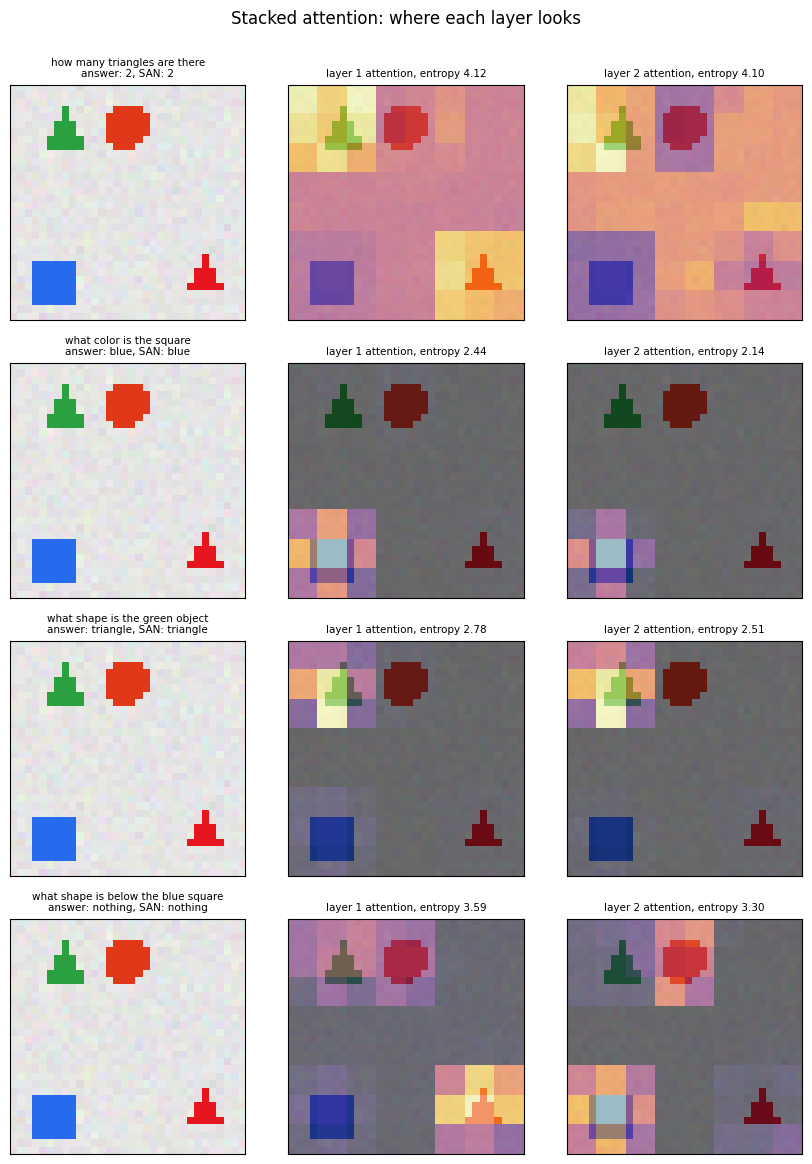

In [15]:
def overlay(ax, img, att, title, fontsize=7.5):
    """Draw the scene with an 8x8 attention map upsampled to 32x32 on top."""
    show_scene(ax, img, title, fontsize=fontsize)
    a = att.detach().cpu().numpy().reshape(8, 8)
    ax.imshow(np.kron(a, np.ones((4, 4))), cmap='inferno', alpha=0.55, vmin=0, vmax=max(a.max(), 1e-6),
              interpolation='nearest')

pred_te = logits_te.argmax(1)
demo_idx = []
for i, t in enumerate(QTYPES):                      # the first correctly answered question of each type
    ok = ((TE['qtype'] == i) & (pred_te == TE['ans'])).nonzero().flatten()
    demo_idx.append(int(ok[0]))
fig, axes = plt.subplots(len(demo_idx), 3, figsize=(8.5, 2.9 * len(demo_idx)))
for r, k in enumerate(demo_idx):
    img = vqa_te['images'][int(TE['scene'][k])]
    show_scene(axes[r, 0], img, f'{vqa_te["questions"][k]}\nanswer: {vqa_te["answers"][k]}, '
               f'SAN: {ANSWERS[int(pred_te[k])]}', fontsize=7.5)
    for l in range(2):
        overlay(axes[r, l + 1], img, atts_te[l][k], f'layer {l + 1} attention, entropy {ent[l][k]:.2f}')
fig.suptitle('Stacked attention: where each layer looks', y=1.0)
plt.tight_layout(); plt.show()

### Widget 2: SAN attention per layer

Pick a test `scene` and one of its questions with `question`. The panels show where layer 1 and layer 2
look, and the title reports the prediction. Compare a count question with a colour question on the same
scene: the query changes, so the attention changes although the image is the same. Watch also for
questions the model gets wrong: the attention map usually shows what it looked at instead.

In [16]:
# Precompute everything the widget needs for the first 60 test scenes (the callback only indexes and plots).
san_demo = {}
for k in range(len(TE['ans'])):
    s = int(TE['scene'][k])
    if s < 60:
        san_demo.setdefault(s, []).append(dict(
            q=vqa_te['questions'][k], a=vqa_te['answers'][k], pred=ANSWERS[int(pred_te[k])],
            att=[atts_te[l][k].detach().cpu() for l in range(2)], ent=[float(ent[l][k]) for l in range(2)]))

def san_widget(scene=0, question=0):
    items = san_demo[scene]
    it = items[min(question, len(items) - 1)]
    img = vqa_te['images'][scene]
    fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.0))
    show_scene(axes[0], img, f'{it["q"]}\nanswer: {it["a"]} | SAN: {it["pred"]}')
    for l in range(2):
        overlay(axes[l + 1], img, it['att'][l], f'layer {l + 1}, entropy {it["ent"][l]:.2f} nats')
    plt.tight_layout(); plt.show()
    print(f'  scene {scene} has {len(items)} question(s); showing question {min(question, len(items) - 1)}')

interact(san_widget, scene=IntSlider(min=0, max=59, step=1, value=0, continuous_update=False),
         question=IntSlider(min=0, max=3, step=1, value=0, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='scene', max=59), IntSlider(valu…

## 5. Hierarchical co-attention

The slide asks the natural next question: *can we do attention on the question as well?* SAN uses the
whole question as a query and attends over the image only. **Hierarchical question-image co-attention**
(Lu et al., NeurIPS 2016) attends over both, and does it at three levels of the question:

- **word level**: the word embeddings $Q^w = [q_1^w, \dots, q_T^w]$;
- **phrase level**: 1-D convolutions over the word embeddings with filter widths 1, 2 and 3 (unigram,
  bigram, trigram), followed by a **max over the three widths** at each position:
  $\hat q^p_{s,t} = \tanh(W_c^s\, q^w_{t:t+s-1})$, $\ q^p_t = \max(\hat q^p_{1,t}, \hat q^p_{2,t}, \hat q^p_{3,t})$;
- **question level**: an LSTM over the phrase features, whose per-step hidden states are $Q^s$.

At each level the model computes a **parallel co-attention** between the question features
$Q \in \mathbb{R}^{d \times T}$ and the image features $V \in \mathbb{R}^{d \times N}$:

$$C = \tanh(Q^\top W_b V) \in \mathbb{R}^{T \times N}, \qquad
H^v = \tanh(W_v V + (W_q Q)\, C), \quad H^q = \tanh(W_q Q + (W_v V)\, C^\top),$$

$$a^v = \mathrm{softmax}(w_{hv}^\top H^v), \quad a^q = \mathrm{softmax}(w_{hq}^\top H^q), \qquad
\hat v = \sum_n a^v_n v_n, \quad \hat q = \sum_t a^q_t q_t .$$

The affinity matrix $C$ scores every (word, region) pair; it is used as a feature for both attention
maps, so the image attention depends on the question and the question attention on the image. The
final answer is predicted **recursively from all three levels**:

$$h^w = \tanh(W_w(\hat q^w + \hat v^w)), \quad h^p = \tanh(W_p[(\hat q^p + \hat v^p), h^w]), \quad
h^s = \tanh(W_s[(\hat q^s + \hat v^s), h^p]), \quad p = \mathrm{softmax}(W_h h^s).$$

We build the question hierarchy first (checking the phrase convolution against `F.conv1d`), then the
co-attention (checking the affinity against explicit loops), then train the whole model.

In [17]:
def phrase_conv_scratch(x, weight, bias, k):
    """Width-k 1-D convolution over a (N, T, d) word sequence, from scratch: right-pad by k-1, gather
    the k-word windows with unfold, contract with the (d_out, d_in, k) filter bank."""
    xp = F.pad(x, (0, 0, 0, k - 1))                          # pad the time axis on the right
    windows = xp.unfold(1, k, 1)                              # (N, T, d_in, k): windows[n,t,i,j] = x[n,t+j,i]
    return torch.einsum('ntij,oij->nto', windows, weight) + bias

class QuestionHierarchy(nn.Module):
    """Word embeddings -> phrase features (widths 1,2,3, max over widths) -> question LSTM states."""
    def __init__(self, d=H):
        super().__init__()
        self.emb = nn.Embedding(V, d, padding_idx=PAD)
        self.convs = nn.ModuleList([nn.Conv1d(d, d, k) for k in (1, 2, 3)])
        self.lstm = nn.LSTM(d, d, batch_first=True)
    def forward(self, tok):
        mask = (tok != PAD)[..., None].float()                      # (N, T, 1)
        q_w = self.emb(tok) * mask                                  # word level
        # phrase level: the from-scratch convolution (verified against F.conv1d below), one per width,
        # then the max over the three widths at every position
        q_p = torch.stack([torch.tanh(phrase_conv_scratch(q_w, c.weight, c.bias, k)) for k, c in zip((1, 2, 3), self.convs)])
        q_p = q_p.max(0).values * mask
        q_s, _ = self.lstm(q_p)                                     # question level: LSTM states per word
        return [q_w, q_p, q_s * mask], mask.squeeze(-1).bool()

# Check the phrase convolution against F.conv1d for each width, using the module's own filters.
set_seed(0)
qh = QuestionHierarchy().to(device)
x_ = torch.randn(4, L_Q, H, device=device)
for k, c in zip((1, 2, 3), qh.convs):
    mine = phrase_conv_scratch(x_, c.weight, c.bias, k)
    ref = F.conv1d(F.pad(x_.transpose(1, 2), (0, k - 1)), c.weight, c.bias).transpose(1, 2)
    assert torch.allclose(mine, ref, atol=1e-5), k
print('phrase_conv_scratch matches F.conv1d for widths 1, 2, 3. OK')
levels, qmask = qh(vqa_tr['qtok'][:5].to(device))
for name, q in zip(('word', 'phrase', 'question'), levels):
    print(f'  {name:9s} level {tuple(q.shape)}  (N, T, d)')
assert all(q.shape == (5, L_Q, H) for q in levels), 'every level keeps one vector per word'

phrase_conv_scratch matches F.conv1d for widths 1, 2, 3. OK
  word      level (5, 10, 64)  (N, T, d)
  phrase    level (5, 10, 64)  (N, T, d)
  question  level (5, 10, 64)  (N, T, d)


In [18]:
class CoAttention(nn.Module):
    """Parallel co-attention (Lu et al. 2016): affinity C, then attention over regions and over words."""
    def __init__(self, d=H, k=H):
        super().__init__()
        self.W_b = nn.Parameter(torch.randn(d, d) / d)      # std 1/d keeps q^T W_b v of order 1, so tanh does not saturate
        self.W_v, self.W_q = nn.Linear(d, k), nn.Linear(d, k)
        self.w_hv, self.w_hq = nn.Linear(k, 1), nn.Linear(k, 1)
    def affinity(self, Q, Vf):
        return torch.tanh((Q @ self.W_b) @ Vf.transpose(1, 2))                     # (N, T, R): C = tanh(Q^T W_b V)
    def forward(self, Q, Vf, qmask):
        C = self.affinity(Q, Vf)
        WqQ, WvV = self.W_q(Q), self.W_v(Vf)                                        # (N,T,k), (N,R,k)
        H_v = torch.tanh(WvV + C.transpose(1, 2) @ WqQ)                             # W_v V + (W_q Q) C
        H_q = torch.tanh(WqQ + C @ WvV)                                             # W_q Q + (W_v V) C^T
        a_v = torch.softmax(self.w_hv(H_v).squeeze(-1), dim=1)                     # (N, R)
        a_q = torch.softmax(self.w_hq(H_q).squeeze(-1).masked_fill(~qmask, -1e9), dim=1)   # (N, T), pads excluded
        v_hat = (a_v[..., None] * Vf).sum(1)
        q_hat = (a_q[..., None] * Q).sum(1)
        return q_hat, v_hat, a_q, a_v

class HieCoAtt(nn.Module):
    """Hierarchical co-attention: word / phrase / question levels, co-attention at each, recursive answer."""
    def __init__(self):
        super().__init__()
        self.qh = QuestionHierarchy()
        self.v_fc = nn.Linear(D_F, H)
        self.coatt = nn.ModuleList([CoAttention() for _ in range(3)])
        self.W_w, self.W_p, self.W_s = nn.Linear(H, H), nn.Linear(2 * H, H), nn.Linear(2 * H, H)
        self.W_h = nn.Linear(H, len(ANSWERS))
    def forward(self, feat, tok, return_att=False):
        Vf = torch.tanh(self.v_fc(feat))
        levels, qmask = self.qh(tok)
        fused, a_qs, a_vs = [], [], []
        for Q, ca in zip(levels, self.coatt):
            q_hat, v_hat, a_q, a_v = ca(Q, Vf, qmask)
            fused.append(q_hat + v_hat); a_qs.append(a_q); a_vs.append(a_v)
        h_w = torch.tanh(self.W_w(fused[0]))
        h_p = torch.tanh(self.W_p(torch.cat([fused[1], h_w], 1)))
        h_s = torch.tanh(self.W_s(torch.cat([fused[2], h_p], 1)))
        logits = self.W_h(h_s)
        return (logits, a_qs, a_vs) if return_att else logits

# Check the einsum affinity against explicit loops over words and regions for one example.
set_seed(0)
ca = CoAttention().to(device)
Q_, V_ = torch.randn(2, L_Q, H, device=device), torch.randn(2, 64, H, device=device)
C_ = ca.affinity(Q_, V_)
C_loop = torch.stack([torch.stack([torch.tanh(Q_[0, t] @ ca.W_b @ V_[0, r]) for r in range(64)])
                      for t in range(L_Q)])
assert torch.allclose(C_[0], C_loop, atol=1e-5)
q_hat, v_hat, a_q, a_v = ca(Q_, V_, torch.ones(2, L_Q, dtype=torch.bool, device=device))
assert torch.allclose(a_q.sum(1), torch.ones(2, device=device), atol=1e-5)
assert torch.allclose(a_v.sum(1), torch.ones(2, device=device), atol=1e-5)
print(f'affinity C {tuple(C_.shape)} = (N, words, regions) matches the double loop (max diff '
      f'{(C_[0] - C_loop).abs().max():.1e}); both attentions sum to 1. OK')

affinity C (2, 10, 64) = (N, words, regions) matches the double loop (max diff 6.9e-07); both attentions sum to 1. OK


In [19]:
print('Hierarchical co-attention')
hie = train_vqa(HieCoAtt, steps=1000)
results['HieCoAtt'], _ = evaluate_vqa(hie)
print(f'  {count_params(hie):,} params | test overall {results["HieCoAtt"]["overall"]:.3f} | ' +
      ' | '.join(f'{t} {results["HieCoAtt"][t]:.3f}' for t in QTYPES))

Hierarchical co-attention
  step    0 | loss 2.587 | batch acc 0.078


  step  250 | loss 0.463 | batch acc 0.773


  step  500 | loss 0.292 | batch acc 0.852


  step  750 | loss 0.258 | batch acc 0.859


  step  999 | loss 0.245 | batch acc 0.914
  trained in 15.6 s
  122,131 params | test overall 0.863 | count 0.983 | color 1.000 | shape 1.000 | spatial 0.510


### 5.a The co-attention maps

The slides show the paper's visualisation: for one question, an image attention map and a question
attention map at each of the three levels. We reproduce it for our model on the first correctly answered
spatial question of the test set. Each row is one level; the left panel overlays the image attention on
the scene and the right panel shows the attention over the words.

Two things are worth noticing. The three image maps look at different things: in this example the word
level splits between the blue square and the red triangle, the phrase level looks at the top row, and
the question level settles on the blue square, the referent. The answer is *nothing* because the cell
below the square is off the grid, so there is no right region to look at, and the recursive head still
answers correctly from three maps that disagree. The question attention reads the sentence only partly
the way a person would: at the word level it splits between *shape*, *below* and *square*, which is a
sensible reading; at the phrase level it prefers *what* and *blue*; and at the question level it is flat
over the LSTM states from *is* onwards, which all summarise the same prefix. The affinity $C$ is a
learned feature that the answer head finds useful, not an explanation, and the paper's own maps show the
same mixture of intuitive and unintuitive choices.

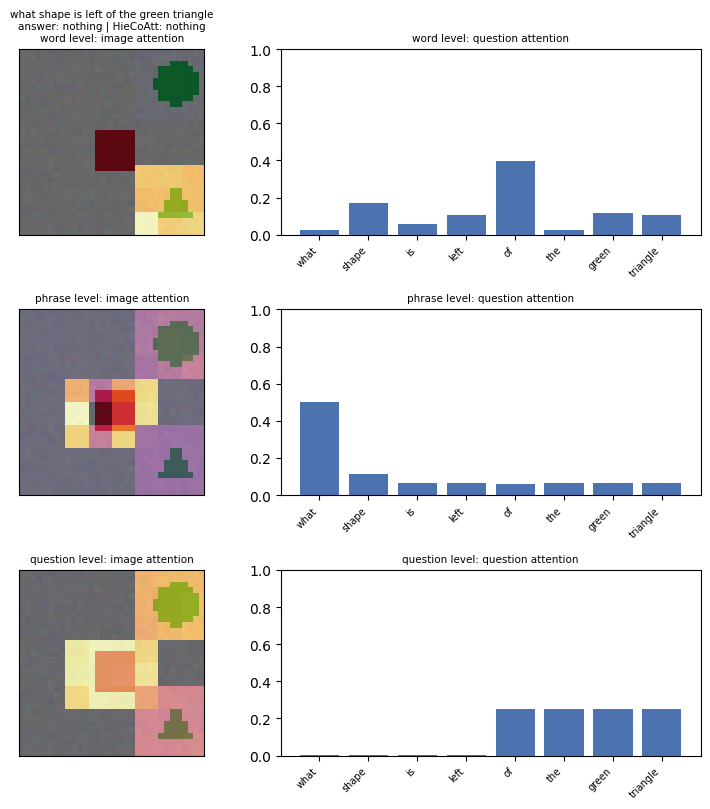

In [20]:
@torch.no_grad()
def coatt_maps(model, img, tok):
    model.eval()
    logits, a_qs, a_vs = model(img, tok, return_att=True)
    model.train()
    return logits, a_qs, a_vs

N_CO = 60                                                        # first 60 test questions
co_logits, co_aq, co_av = coatt_maps(hie, FEAT_TE[TE['scene'][:N_CO]], TE['qtok'][:N_CO])
co_pred = co_logits.argmax(1)
LEVELS = ['word', 'phrase', 'question']

def draw_coattention(k, axes):
    img = vqa_te['images'][int(TE['scene'][k])]
    words = vqa_te['questions'][k].split()
    for l in range(3):
        overlay(axes[l, 0], img, co_av[l][k], f'{LEVELS[l]} level: image attention')
        a = co_aq[l][k][:len(words)].detach().cpu().numpy()
        axes[l, 1].bar(range(len(words)), a, color='#4C72B0')
        axes[l, 1].set_xticks(range(len(words))); axes[l, 1].set_xticklabels(words, rotation=45, fontsize=7, ha='right')
        axes[l, 1].set_ylim(0, 1); axes[l, 1].set_title(f'{LEVELS[l]} level: question attention', fontsize=7.5)
    axes[0, 0].set_title(f'{vqa_te["questions"][k]}\nanswer: {vqa_te["answers"][k]} | HieCoAtt: '
                         f'{ANSWERS[int(co_pred[k])]}\nword level: image attention', fontsize=7.5)

k0 = int(((TE['qtype'][:N_CO] == 3) & (co_pred == TE['ans'][:N_CO])).nonzero().flatten()[0])
fig, axes = plt.subplots(3, 2, figsize=(7.5, 8.2), gridspec_kw={'width_ratios': [1, 1.6]})
draw_coattention(k0, axes)
plt.tight_layout(); plt.show()

### Widget 3: co-attention map viewer

Drag `question` through the first 60 test questions. Compare the three image maps first: they often
disagree, and the level that lands on the object the question names is not always the same one. Then
look at the question attention: for a count question, see whether any level singles out the noun being
counted; for a spatial question, whether the relation word gets weight; and notice how often a level
prefers a function word next to the content word instead of the content word itself.

In [21]:
def coatt_widget(question=0):
    fig, axes = plt.subplots(3, 2, figsize=(7.5, 8.2), gridspec_kw={'width_ratios': [1, 1.6]})
    draw_coattention(question, axes)
    plt.tight_layout(); plt.show()

interact(coatt_widget, question=IntSlider(min=0, max=N_CO - 1, step=1, value=k0, continuous_update=False));

interactive(children=(IntSlider(value=15, continuous_update=False, description='question', max=59), Output()),…

## 6. Accuracy by question type

COCO-QA and VQA report accuracy per question type, because the types are not equally hard and a single
number hides which capability a model is missing. Here is the table for our four models, with the
no-image prior (the most frequent training answer for each type) as the floor.

  model               overall    count    color    shape  spatial
  prior (no image)      0.385    0.385    0.246    0.323    0.549
  iBOWIMG               0.612    0.692    0.563    0.640    0.544
  LSTM + image          0.613    0.683    0.605    0.642    0.521
  SAN                   0.800    0.725    1.000    1.000    0.541
  HieCoAtt              0.863    0.983    1.000    1.000    0.510

  best overall: HieCoAtt (0.863); hardest type for it: spatial


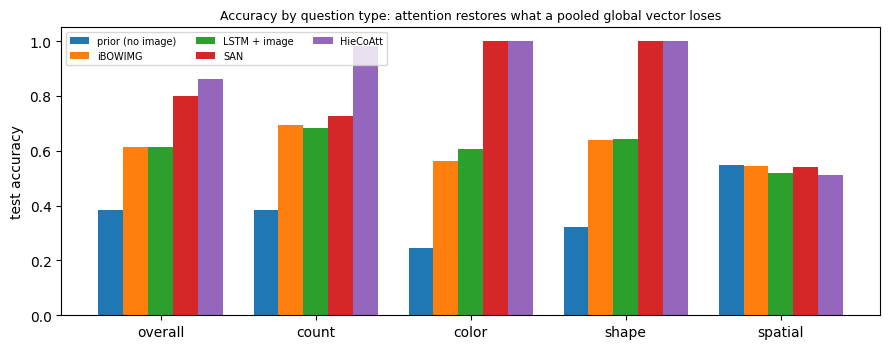

In [22]:
order = ['prior (no image)', 'iBOWIMG', 'LSTM + image', 'SAN', 'HieCoAtt']
print(f'  {"model":18s} {"overall":>8s} ' + ' '.join(f'{t:>8s}' for t in QTYPES))
for name in order:
    r = results[name]
    print(f'  {name:18s} {r["overall"]:8.3f} ' + ' '.join(f'{r[t]:8.3f}' for t in QTYPES))
best = max(order[1:], key=lambda n: results[n]['overall'])
print(f'\n  best overall: {best} ({results[best]["overall"]:.3f}); hardest type for it: '
      f'{min(QTYPES, key=lambda t: results[best][t])}')

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(QTYPES) + 1)
w = 0.16
for j, name in enumerate(order):
    vals = [results[name]['overall']] + [results[name][t] for t in QTYPES]
    ax.bar(x + (j - 2) * w, vals, w, label=name)
ax.set_xticks(x); ax.set_xticklabels(['overall'] + QTYPES)
ax.set_ylim(0, 1.05); ax.set_ylabel('test accuracy'); ax.legend(fontsize=7, ncol=3)
ax.set_title('Accuracy by question type: attention restores what a pooled global vector loses', fontsize=9)
plt.tight_layout(); plt.show()

The table says three things.

- **Pooling loses the binding, attention restores it.** "What color is the circle" needs the colour that
  goes *with* the circle. A mean over regions still contains every colour and every shape, but not which
  colour was where, so the two global-vector baselines answer colour and shape questions at 0.56 to 0.64,
  barely above a coin toss among the values present, while both attention models are perfect on them:
  attending to the circle and reading its colour is exactly what the mean cannot do.
- **Counting is hard for a normalised attention.** SAN's weights sum to 1, so the attended vector of two
  red objects looks much like that of one, and SAN reaches only 0.73 on count questions, barely above the
  baselines. The hierarchical model reaches 0.98. Its affinity matrix $C$ is *not* normalised over
  regions: $H^v$ and $H^q$ receive sums over every region that matches a word, so the number of matches
  can show up in their magnitude, which a softmax-weighted mean cannot express. Dedicated counting modules
  were later proposed for exactly this limitation of soft attention.
- **Relations need a second hop that nobody here takes.** On spatial questions every model, attention
  included, sits at the no-image prior (0.52 to 0.55 against 0.549: predicting *nothing* is as good as
  any of them). The map finds the referent, but reading its *neighbour* means shifting attention by one
  cell, and neither architecture has an operation that does that. CLEVR was built to expose this gap,
  and the neural module networks in the slide's reading list attack it with an explicit *relocate*
  module.

### Widget 4: question-type chooser

Pick a `qtype`. The bars are the five models on that type only, with the prior as the floor. Look at
*color* and *shape* for the binding effect, at *count* for the gap between SAN and the co-attention
model, and at *spatial* for how nothing separates any model from the no-image prior.

In [23]:
def qtype_widget(qtype='spatial'):
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    vals = [results[n][qtype] for n in order]
    bars = ax.bar(range(len(order)), vals, color=['#999999', '#C44E52', '#DD8452', '#4C72B0', '#55A868'])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, fontsize=7.5)
    ax.set_ylim(0, 1.1); ax.set_ylabel('test accuracy')
    ax.set_title(f'{qtype} questions ({int((TE["qtype"] == QTYPES.index(qtype)).sum())} in the test set)')
    plt.tight_layout(); plt.show()

interact(qtype_widget, qtype=Dropdown(options=QTYPES, value='spatial'));

interactive(children=(Dropdown(description='qtype', index=3, options=('count', 'color', 'shape', 'spatial'), v…

## 7. Visual Dialog: the task and a synthetic dialog

**Visual Dialog** (Das et al., CVPR 2017) turns one question into a conversation. Given

- an image $I$,
- a **human dialog history** $(Q_1, A_1), (Q_2, A_2), \dots, (Q_{t-1}, A_{t-1})$,
- and a **follow-up question** $Q_t$,

the task is to produce a free-form natural language answer $A_t$. The point of the CloudCV demo on the
slides is **coreference**: after a round such as "is it a dog?" / "yes", a follow-up "what colour is
**it**" cannot be answered without the history, since a model without it cannot even tell what *it*
refers to. The VisDial dataset was collected by pairing two people in a
chat, one seeing the image and the other only its caption; the paper reports about 123K COCO images with
10 rounds of questions and answers each, roughly 1.2M question-answer pairs.

Our synthetic dialogs are built on the scenes of Section 2, with five rounds each, and they use exactly
this kind of **coreference**. The first round establishes a referent ("where is the red circle", "what
color is the triangle"), and later rounds may ask about "it": "what is left of it", "where is it", "what
shape is it". Other rounds ask fresh questions. Unlike Section 2, answers are short **sequences** ("it is
red", "a green square", "two blue circles", "top left", "nothing") so that a generative decoder has
something to generate and there are enough distinct answers to rank.

In [24]:
NUM = ['no', 'one', 'two', 'three', 'four']
L_A, L_H = 6, L_Q + 4                   # answer with BOS/EOS; one history round = question + answer
T_ROUNDS = 5

def count_phrase(n, singular, plural):
    """'no red circles', 'one red circle', 'two red circles'."""
    return f'no {plural}' if n == 0 else (f'one {singular}' if n == 1 else f'{NUM[n]} {plural}')

def describe(o):
    return f'a {o["color"]} {o["shape"]}' if o else 'nothing'

TEMPLATES = ['how many {c} {s}s are there', 'how many {s}s are there', 'how many {c} objects are there',
             'how many objects are there', 'where is the {c} {s}', 'what color is the {s}',
             'what shape is the {c} object', 'what is {r} it', 'where is it', 'what color is it',
             'what shape is it']

def count_question(objs, rng):
    form = int(rng.integers(4))
    present = objs if rng.random() < 0.7 else None          # mostly ask about things that exist
    c = pick(rng, present)['color'] if present else pick(rng, COLORS)
    s = pick(rng, present)['shape'] if present else pick(rng, SHAPES)
    if form == 0:
        n = sum(o['color'] == c and o['shape'] == s for o in objs)
        return 0, f'how many {c} {s}s are there', count_phrase(n, f'{c} {s}', f'{c} {s}s')
    if form == 1:
        n = sum(o['shape'] == s for o in objs)
        return 1, f'how many {s}s are there', count_phrase(n, s, s + 's')
    if form == 2:
        n = sum(o['color'] == c for o in objs)
        return 2, f'how many {c} objects are there', count_phrase(n, f'{c} object', f'{c} objects')
    return 3, 'how many objects are there', count_phrase(len(objs), 'object', 'objects')

def make_dialog(objs, rng, T=T_ROUNDS):
    """A T-round dialog: list of (template id, question, answer, refers_to_history)."""
    rounds, focus, asked = [], None, set()
    for t in range(T):
        follow = []
        if focus is not None:
            follow += [(8, None)] * ('where' not in asked) + [(9, None)] * ('color' not in asked) \
                      + [(10, None)] * ('shape' not in asked) + [(7, r) for r in REL if r not in asked]
        if follow and rng.random() < 0.6:
            tpl, r = pick(rng, follow)
            if tpl == 7:
                q, a = f'what is {r} it', describe(neighbour(objs, focus, r)); asked.add(r)
            elif tpl == 8:
                q, a = 'where is it', f'{ROWS[focus["row"]]} {COLS[focus["col"]]}'; asked.add('where')
            elif tpl == 9:
                q, a = 'what color is it', f'it is {focus["color"]}'; asked.add('color')
            else:
                q, a = 'what shape is it', f'it is a {focus["shape"]}'; asked.add('shape')
            rounds.append((tpl, q, a, True))
            continue
        setters = [(4, o) for o in unique_pairs(objs)] + [(5, o) for o in unique_by(objs, 'shape')] \
                  + [(6, o) for o in unique_by(objs, 'color')]
        if setters and rng.random() < (0.9 if t == 0 else 0.5):
            tpl, o = pick(rng, setters)
            focus = o
            if tpl == 4:
                q, a, asked = f'where is the {o["color"]} {o["shape"]}', f'{ROWS[o["row"]]} {COLS[o["col"]]}', {'where'}
            elif tpl == 5:
                q, a, asked = f'what color is the {o["shape"]}', f'it is {o["color"]}', {'color'}
            else:
                q, a, asked = f'what shape is the {o["color"]} object', f'it is a {o["shape"]}', {'shape'}
            rounds.append((tpl, q, a, False))
        else:
            tpl, q, a = count_question(objs, rng)
            rounds.append((tpl, q, a, False))
    return rounds

# The fixed answer space: every phrase the templates can produce.
ANS_STR = sorted({count_phrase(n, f'{c} {s}', f'{c} {s}s') for n in range(5) for c in COLORS for s in SHAPES}
                 | {count_phrase(n, s, s + 's') for n in range(5) for s in SHAPES}
                 | {count_phrase(n, f'{c} object', f'{c} objects') for n in range(5) for c in COLORS}
                 | {count_phrase(n, 'object', 'objects') for n in range(5)}
                 | {f'{r} {c}' for r in ROWS for c in COLS} | {f'it is {c}' for c in COLORS}
                 | {f'it is a {s}' for s in SHAPES} | {f'a {c} {s}' for c in COLORS for s in SHAPES} | {'nothing'})
AS2I = {a: i for i, a in enumerate(ANS_STR)}
N_ANS = len(ANS_STR)

def build_dialogs(vqa, seed):
    """Dialogs on the scenes of a VQA split: tensors indexed [dialog, round]."""
    rng = np.random.default_rng(seed)
    dl = [make_dialog(objs, rng) for objs in vqa['objs']]
    q = torch.tensor([[tokenize(r[1], L_Q) for r in d] for d in dl])
    a = torch.tensor([[tokenize(r[2], L_A, bos_eos=True) for r in d] for d in dl])
    h = torch.tensor([[tokenize(r[1] + ' ' + r[2], L_H) for r in d] for d in dl])
    return dict(rounds=dl, q=q, a=a, h=h,
                ans=torch.tensor([[AS2I[r[2]] for r in d] for d in dl]),
                tpl=torch.tensor([[r[0] for r in d] for d in dl]),
                follow=torch.tensor([[r[3] for r in d] for d in dl]))

dlg_tr, dlg_te = build_dialogs(vqa_tr, seed=11), build_dialogs(vqa_te, seed=12)
n_tr, n_te = dlg_tr['q'].shape[0], dlg_te['q'].shape[0]
print(f'train: {n_tr} dialogs x {T_ROUNDS} rounds = {n_tr * T_ROUNDS} | test: {n_te} x {T_ROUNDS} = {n_te * T_ROUNDS}')
print(f'answer space: {N_ANS} distinct phrases | rounds that refer to history ("it"): '
      f'{100 * dlg_tr["follow"].float().mean():.1f}% of train rounds')
print(f'question tokens {tuple(dlg_tr["q"].shape)}, answer tokens {tuple(dlg_tr["a"].shape)}, '
      f'history rounds {tuple(dlg_tr["h"].shape)}')
assert all(r[2] in AS2I for d in dlg_tr['rounds'] + dlg_te['rounds'] for r in d)

for n in (0, 1):
    print(f'\ntrain dialog {n}, {len(vqa_tr["objs"][n])} objects:')
    for t, (tpl, q, a, fol) in enumerate(dlg_tr['rounds'][n]):
        print((f'  Q{t + 1}: {q:36s} A{t + 1}: {a:20s}' + ('  <- needs history' if fol else '')).rstrip())

train: 4000 dialogs x 5 rounds = 20000 | test: 400 x 5 = 2000
answer space: 129 distinct phrases | rounds that refer to history ("it"): 44.0% of train rounds
question tokens (4000, 5, 10), answer tokens (4000, 5, 6), history rounds (4000, 5, 14)

train dialog 0, 2 objects:
  Q1: what shape is the blue object        A1: it is a circle
  Q2: what color is the circle             A2: it is blue
  Q3: what is left of it                   A3: nothing               <- needs history
  Q4: what is below it                     A4: nothing               <- needs history
  Q5: what is above it                     A5: nothing               <- needs history

train dialog 1, 2 objects:
  Q1: how many objects are there           A1: two objects
  Q2: how many yellow triangles are there  A2: two yellow triangles
  Q3: how many triangles are there         A3: two triangles
  Q4: how many yellow triangles are there  A4: two yellow triangles
  Q5: how many objects are there           A5: two objects


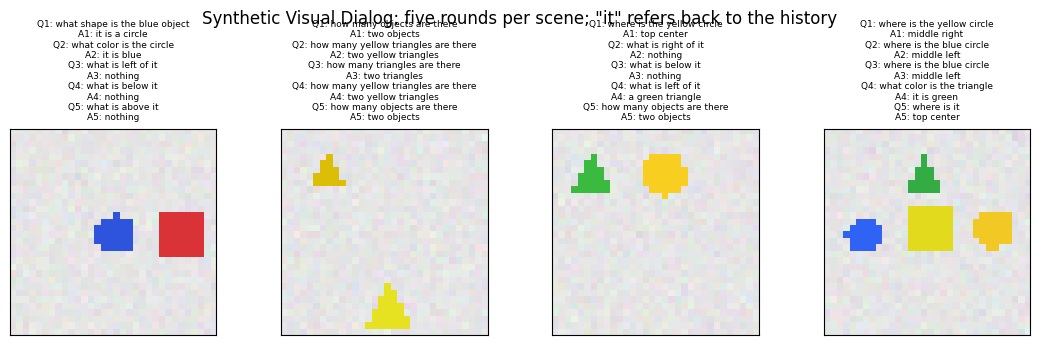

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3.4))
for k, ax in enumerate(axes):
    text = '\n'.join(f'Q{t + 1}: {q}\nA{t + 1}: {a}' for t, (_, q, a, _) in enumerate(dlg_tr['rounds'][k]))
    show_scene(ax, vqa_tr['images'][k], text, fontsize=6.5)
fig.suptitle('Synthetic Visual Dialog: five rounds per scene; "it" refers back to the history', y=1.0)
plt.tight_layout(); plt.show()

## 8. Evaluating Visual Dialog by ranking

The slides call evaluation "a fundamental challenge in dialog systems", citing Liu et al. (EMNLP 2016,
*How NOT to evaluate your dialogue system*): word-overlap metrics such as **BLEU, METEOR and ROUGE
correlate poorly with human judgement** for dialog, since "no", "nope" and "I don't think so" share no
words, and a human Turing test is **expensive and subjective**. Visual Dialog sidesteps generation
quality altogether and turns evaluation into **retrieval**:

> "100 answer options: Answers to 50 most similar questions, 30 popular answers, 20 random answers.
> Evaluation Task: Rank the list of 100 options. Accuracy/Error: Mean rank w.r.t. ground truth, Mean
> reciprocal rank."

So the model is given the image, the history, the follow-up question and the 100 options, and it must
**rank the 100 options**; the metrics are the **mean rank** of the ground-truth answer and its **mean
reciprocal rank**.

Recall at $k$ (is the true answer in the top $k$?) for $k = 1, 5, 10$ completes the standard table. We
implement the metrics from scratch and check them against a brute-force loop, then reproduce the
candidate construction for our test rounds: 50 answers to the most similar questions (here, the most
frequent answers to training questions with the same template), the 30 most popular answers overall,
and 20 random ones, deduplicated and topped up to exactly 100 distinct options containing the truth.

In [26]:
def gt_rank(scores, gt_pos):
    """Rank (1 = best) of the ground-truth option: 1 + the number of options scoring strictly higher."""
    gt_score = scores.gather(1, gt_pos[:, None])
    return 1 + (scores > gt_score).sum(1)

def ranking_metrics(ranks):
    """Mean rank, mean reciprocal rank and recall@1/5/10 from a tensor of ranks."""
    r = ranks.detach().cpu().double()                     # small; float64 on the CPU for exact averages
    return {'mean rank': r.mean().item(), 'MRR': (1.0 / r).mean().item(),
            'R@1': (r <= 1).float().mean().item(), 'R@5': (r <= 5).float().mean().item(),
            'R@10': (r <= 10).float().mean().item()}

# Brute-force reference: sort each row and find the ground truth.
g = torch.Generator().manual_seed(0)
sc = torch.randn(50, 100, generator=g)
gt = torch.randint(0, 100, (50,), generator=g)
ranks_bf = []
for n in range(50):
    order = sorted(range(100), key=lambda j: -sc[n, j].item())
    ranks_bf.append(order.index(int(gt[n])) + 1)
assert torch.equal(gt_rank(sc, gt), torch.tensor(ranks_bf))
m_bf = {'mean rank': np.mean(ranks_bf), 'MRR': np.mean([1 / r for r in ranks_bf]),
        'R@1': np.mean([r <= 1 for r in ranks_bf]), 'R@5': np.mean([r <= 5 for r in ranks_bf]),
        'R@10': np.mean([r <= 10 for r in ranks_bf])}
m_ = ranking_metrics(gt_rank(sc, gt))
assert all(abs(m_[k] - m_bf[k]) < 1e-6 for k in m_)
print('gt_rank and ranking_metrics match the brute-force sort on 50 random rows. OK')

# What a random model scores, so any real number has a baseline to beat.
n_options = 100
assert 50 + 30 + 20 == n_options, 'the option-set decomposition should total 100'
trials = 200_000
ranks = torch.randint(1, n_options + 1, (trials,), generator=g).float()
mean_rank, mrr = ranks.mean().item(), (1.0 / ranks).mean().item()
theory_rank = (n_options + 1) / 2
theory_mrr = sum(1.0 / k for k in range(1, n_options + 1)) / n_options
print(f'\n  random guessing over {n_options} options:')
print(f'    mean rank : {mean_rank:6.2f}   (theory {theory_rank:.2f})')
print(f'    MRR       : {mrr:6.4f}   (theory {theory_mrr:.4f})')
print(f'    R@1 {1 / n_options:.3f}, R@5 {5 / n_options:.3f}, R@10 {10 / n_options:.3f} (theory)')
assert abs(mean_rank - theory_rank) < 0.5 and abs(mrr - theory_mrr) < 0.01
print('  lower mean rank is better, higher MRR is better; a model must beat 50.5 and 0.052 first')

gt_rank and ranking_metrics match the brute-force sort on 50 random rows. OK

  random guessing over 100 options:
    mean rank :  50.49   (theory 50.50)
    MRR       : 0.0520   (theory 0.0519)
    R@1 0.010, R@5 0.050, R@10 0.100 (theory)
  lower mean rank is better, higher MRR is better; a model must beat 50.5 and 0.052 first


In [27]:
# Build the 100-option candidate lists for every test round, as the slide describes.
by_tpl = {t: Counter(dlg_tr['ans'][dlg_tr['tpl'] == t].tolist()) for t in range(len(TEMPLATES))}
popular = Counter(dlg_tr['ans'].flatten().tolist())

def make_candidates(tpl, gt_id, rng, n=n_options):
    similar = [a for a, _ in by_tpl[tpl].most_common(50)]     # answers to the 50 most similar questions
    pop = [a for a, _ in popular.most_common(30)]             # 30 popular answers
    rand = rng.choice(N_ANS, 20, replace=False).tolist()      # 20 random answers
    out, seen = [], set()
    for a in [gt_id] + similar + pop + rand:
        if a not in seen:
            seen.add(a); out.append(a)
    while len(out) < n:                                       # top up to exactly 100 distinct options
        a = int(rng.integers(N_ANS))
        if a not in seen:
            seen.add(a); out.append(a)
    out = [out[i] for i in rng.permutation(n)]                # shuffle so the truth is not always first
    return out, out.index(gt_id)

rng = np.random.default_rng(5)
cand, gt_pos = [], []
for n in range(n_te):
    for t in range(T_ROUNDS):
        c, p = make_candidates(int(dlg_te['tpl'][n, t]), int(dlg_te['ans'][n, t]), rng)
        cand.append(c); gt_pos.append(p)
CAND = torch.tensor(cand).view(n_te, T_ROUNDS, n_options)
GT_POS = torch.tensor(gt_pos).view(n_te, T_ROUNDS)
assert (CAND.gather(2, GT_POS[..., None]).squeeze(-1) == dlg_te['ans']).all(), 'the truth must be in its list'
assert all(len(set(c)) == n_options for c in cand), 'options must be distinct'
print(f'candidate lists {tuple(CAND.shape)} = (dialogs, rounds, options); each has 100 distinct answers incl. the truth')
print('example, test dialog 0 round 1:')
print(f'  Q: {dlg_te["rounds"][0][0][1]}   truth: "{dlg_te["rounds"][0][0][2]}" at position {int(GT_POS[0, 0])}')
print('  a few options:', ', '.join(f'"{ANS_STR[a]}"' for a in cand[0][:6]), '...')

candidate lists (400, 5, 100) = (dialogs, rounds, options); each has 100 distinct answers incl. the truth
example, test dialog 0 round 1:
  Q: what shape is the green object   truth: "it is a triangle" at position 84
  a few options: "two green squares", "one circle", "it is red", "no red objects", "one green square", "four red triangles" ...


## 9. Encoders and decoders for Visual Dialog

The paper frames every model as an **encoder-decoder**: the encoder turns $(I, H, Q_t)$ into a vector
$e$, and the decoder turns $e$ into an answer. The slides list three encoders and two decoders.

**Encoders** (they differ only in how they compress the history):

- **Late Fusion (LF)**: encode the image with the CNN, the whole history as one long string with an LSTM,
  and the question with another LSTM; concatenate the three and project. The paper's sizes are
  4096 + 512 + 512 = 5120 in, 512 out.
- **Hierarchical Recurrent Encoder (HRE)**: encode each round $(Q_i, A_i)$ with an LSTM, then run a
  **dialog-level LSTM** over the sequence of round encodings, so the history is summarised recurrently.
- **Memory Network (MN)**: encode each round into a **memory bank** of $t$ vectors; the question (fused
  with the image) attends over the bank with a softmax, reads a weighted sum, and adds it to the query.

**Decoders**:

- **Generative (LSTM)**: an LSTM initialised with $e$ generates the answer. Training maximises the
  log-likelihood of the ground-truth answer sequence; at evaluation the model's log-likelihood of each
  candidate ranks the 100 options.
- **Discriminative (softmax)**: an LSTM encodes each answer option; the score of an option is the **dot
  product** of $e$ with the option encoding; a softmax over the options (in the paper; over all 129
  answer phrases in our version, see 9.b) gives a posterior; training
  maximises the log-likelihood of the correct option; at evaluation the options are ranked by posterior.

First the shape traces at the paper's sizes, then our small versions trained on the synthetic dialogs.

In [28]:
# The three encoders differ only in how they compress the history.
d_img, d_lstm = 4096, 512
t_rounds = 5

# Late Fusion: concatenate everything, once.
late = torch.cat([torch.randn(d_img), torch.randn(d_lstm), torch.randn(d_lstm)])
assert late.shape == (d_img + 2 * d_lstm,) == (5120,)

# Memory Network: attend over a t x 512 bank of per-round history encodings.
memory = torch.randn(t_rounds, d_lstm)
q = torch.randn(d_lstm)
att_hist = torch.softmax(memory @ q, dim=0)
read = att_hist @ memory
refined = read + q

assert att_hist.shape == (t_rounds,) and torch.allclose(att_hist.sum(), torch.tensor(1.0), atol=1e-5)
assert refined.shape == (d_lstm,)

print(f'  Late Fusion   : concat {d_img} + {d_lstm} + {d_lstm} = {late.shape[0]} -> 512')
print(f'  Memory Network: attend over a {t_rounds} x {d_lstm} memory bank')
print(f'                  attention length grows with the dialog round ({t_rounds} now), summing to 1')
print(f'  Hierarchical  : a dialog-level LSTM recurs over the rounds instead of attending')

  Late Fusion   : concat 4096 + 512 + 512 = 5120 -> 512
  Memory Network: attend over a 5 x 512 memory bank
                  attention length grows with the dialog round (5 now), summing to 1
  Hierarchical  : a dialog-level LSTM recurs over the rounds instead of attending


In [29]:
# The discriminative decoder scores each option by dot product, then softmaxes.
# Softmax is monotone, so ranking by posterior "should" equal ranking by raw score.
# In floating point that is not quite true, and the reason is worth seeing.
d_enc = 512
g_ = torch.Generator().manual_seed(0)
encoding = torch.randn(1, d_enc, generator=g_)
options = torch.randn(1, n_options, d_enc, generator=g_)       # LSTM encodings of the 100 candidates

dots = torch.bmm(options, encoding.unsqueeze(2)).squeeze(2)   # (1, 100): 512-d dot products spread over ~100 units
posterior = torch.softmax(dots, dim=1)

assert torch.allclose(posterior.sum(1), torch.ones(1), atol=1e-5)
n_underflow = int((posterior == 0).sum())
assert n_underflow > 0, 'this seed should produce a saturated tail'

rank_by_dot = dots.argsort(dim=1, descending=True)
rank_by_post = posterior.argsort(dim=1, descending=True)
same_order = torch.equal(rank_by_dot, rank_by_post)     # depends on how argsort breaks the ties

print(f'  raw dot products span {dots.min():.1f} to {dots.max():.1f}')
print(f'  after softmax, {n_underflow} of {n_options} posteriors underflow to exactly 0.0, so they are tied')
print(f'  ranking by posterior {"happens to match" if same_order else "differs from"} ranking by dot on this machine')

# The order is genuinely preserved by the maths; float32 just cannot represent the tail.
# log_softmax is monotone AND numerically stable, so it recovers the exact order (this IS deterministic).
logpost = torch.log_softmax(dots, dim=1)
assert torch.equal(rank_by_dot, logpost.argsort(dim=1, descending=True)), 'log-softmax must preserve the order'
print('  ranking by log-softmax == ranking by dot?  True (asserted)')
print('\n  softmax IS monotone, so the ranking is mathematically identical.')
print(f'  but the {n_underflow} zero posteriors are tied, so argsort may order them differently from the dot')
print(f'  products; it {"did not" if same_order else "did"} here, and the outcome depends on the sort kernel.')
print('  Rank on scores or log-probabilities, never on saturated probabilities.')

  raw dot products span -76.1 to 66.8
  after softmax, 11 of 100 posteriors underflow to exactly 0.0, so they are tied
  ranking by posterior differs from ranking by dot on this machine
  ranking by log-softmax == ranking by dot?  True (asserted)

  softmax IS monotone, so the ranking is mathematically identical.
  but the 11 zero posteriors are tied, so argsort may order them differently from the dot
  products; it did here, and the outcome depends on the sort kernel.
  Rank on scores or log-probabilities, never on saturated probabilities.


### 9.a Small encoders

As in VisDial, the image encoder is a **frozen** CNN: we reuse the frozen region grid of Section 3,
flattened to one 64 x 34 vector per scene (VisDial flattens VGG's fc7 the same way), so the dialog
models only learn how to use it. Every encoder shares the same three building blocks (a question LSTM, a history LSTM
that encodes one round or the concatenated history, and a linear image projection) and differs only in
the history path. A fourth encoder, **no history**, drops the history altogether; it is the control that
tells us how much the history is worth.

The memory network's attention over the bank is written from scratch and checked against
`F.scaled_dot_product_attention` with the round mask, since it is exactly a masked dot-product attention
with one query.

In [30]:
DFEAT_TR, DFEAT_TE = FEAT_TR.flatten(1), FEAT_TE.flatten(1)     # (4000, 64 * 34): the frozen grid as one vector
DT = {k: dlg_tr[k].to(device) for k in ('q', 'a', 'h', 'ans', 'tpl', 'follow')}
DE = {k: dlg_te[k].to(device) for k in ('q', 'a', 'h', 'ans', 'tpl', 'follow')}
ANS_TOK = torch.tensor([tokenize(s, L_A - 2) for s in ANS_STR], device=device)           # for the option encoder
ANS_TOK_BOS = torch.tensor([tokenize(s, L_A, bos_eos=True) for s in ANS_STR], device=device)   # for the generator
print('frozen image features', tuple(DFEAT_TR.shape), '| answer options', tuple(ANS_TOK.shape))

def concat_history(hist, hmask):
    """(B, T, L_H) round tokens -> (B, T*L_H) with the visible rounds' words moved to the front, in order."""
    tok = (hist * hmask[..., None]).flatten(1)
    order = torch.argsort((tok == PAD).long(), dim=1, stable=True)     # non-pad first, order preserved
    return torch.gather(tok, 1, order)

def memory_attention(memory, query, hmask):
    """From scratch: softmax over the visible rounds of memory . query, then the weighted read."""
    scores = (memory * query[:, None, :]).sum(-1).masked_fill(~hmask, -1e9)
    alpha = torch.softmax(scores, dim=1) * hmask.float()               # rounds not yet spoken get weight 0
    return (alpha[..., None] * memory).sum(1), alpha

class DialogEncoder(nn.Module):
    """Late fusion / hierarchical recurrent / memory network / no-history encoders of (I, H, Q_t)."""
    def __init__(self, kind, d=H):
        super().__init__()
        self.kind = kind
        self.emb = nn.Embedding(V, d, padding_idx=PAD)
        self.q_enc = QuestionLSTM(d, emb=self.emb)
        self.h_enc = QuestionLSTM(d, emb=self.emb)               # one round, or the concatenated history
        self.img_fc = nn.Linear(64 * D_F, d)
        if kind == 'HRE':
            self.dialog_lstm = nn.LSTM(d, d, batch_first=True)
        n_in = {'LF': 3, 'HRE': 3, 'MN': 2, 'none': 2}[kind]
        self.out = nn.Linear(n_in * d, d)
    def forward(self, img, q, hist, hmask):
        B, T, L = hist.shape
        v = torch.tanh(self.img_fc(img))
        u = self.q_enc(q)[1]
        if self.kind == 'none':
            return torch.tanh(self.out(torch.cat([v, u], 1))), None
        if self.kind == 'LF':
            h = self.h_enc(concat_history(hist, hmask))[1]
            return torch.tanh(self.out(torch.cat([v, u, h], 1))), None
        rounds = self.h_enc((hist * hmask[..., None]).view(B * T, L))[1].view(B, T, -1)   # one vector per round
        if self.kind == 'HRE':
            # The visible rounds need not be a prefix (a truncated history keeps rounds t-k..t-1), so move
            # them to the front, in order, before packing; mirrors concat_history for the LF encoder.
            order = torch.argsort((~hmask).long(), dim=1, stable=True)
            rounds = torch.gather(rounds, 1, order[..., None].expand(-1, -1, rounds.shape[-1]))
            lengths = hmask.sum(1)
            packed = pack_padded_sequence(rounds, lengths.clamp(min=1).cpu(), batch_first=True, enforce_sorted=False)
            _, (hd, _) = self.dialog_lstm(packed)
            hd = hd[-1] * (lengths > 0).float()[:, None]           # no history yet -> zero state
            return torch.tanh(self.out(torch.cat([v, u, hd], 1))), None
        query = torch.tanh(self.out(torch.cat([v, u], 1)))          # MN: question + image is the query
        read, alpha = memory_attention(rounds, query, hmask)
        return torch.tanh(query + read), alpha

# Check memory_attention against F.scaled_dot_product_attention with the same mask (scale 1, one query).
set_seed(0)
mem_ = torch.randn(4, T_ROUNDS, H, device=device)
qry_ = torch.randn(4, H, device=device)
hm_ = torch.arange(T_ROUNDS, device=device)[None] < torch.tensor([1, 2, 3, 5], device=device)[:, None]
read_, alpha_ = memory_attention(mem_, qry_, hm_)
ref_ = F.scaled_dot_product_attention(qry_[:, None, None, :], mem_[:, None], mem_[:, None],
                                      attn_mask=hm_[:, None, None, :], scale=1.0)[:, 0, 0]
assert torch.allclose(read_, ref_, atol=1e-5)
assert torch.allclose(alpha_.sum(1), torch.ones(4, device=device), atol=1e-5) and (alpha_[~hm_] == 0).all()
print(f'memory_attention matches F.scaled_dot_product_attention with the round mask (max diff '
      f'{(read_ - ref_).abs().max():.1e}); hidden rounds get weight 0. OK')

# Check the HRE compaction: a truncated history that shows only round 2 (asking at round 3 with one round
# visible) must encode exactly like a fresh history with that same round in slot 0, because the dialog
# LSTM should read the visible rounds, not the first slots.
set_seed(0)
hre_ = DialogEncoder('HRE').to(device).eval()
img_, q_, hist_ = DFEAT_TE[:4], DE['q'][:4, 3], DE['h'][:4]
only_round2 = torch.arange(T_ROUNDS, device=device)[None].expand(4, -1) == 2
only_round0 = torch.arange(T_ROUNDS, device=device)[None].expand(4, -1) == 0
with torch.no_grad():
    e_trunc = hre_(img_, q_, hist_, only_round2)[0]
    e_moved = hre_(img_, q_, torch.roll(hist_, -2, dims=1), only_round0)[0]
    e_empty = hre_(img_, q_, hist_, torch.zeros_like(only_round0))[0]
assert torch.allclose(e_trunc, e_moved, atol=1e-5), 'HRE must read the visible rounds, wherever they sit'
assert not torch.allclose(e_trunc, e_empty, atol=1e-3), 'HRE with one visible round must differ from no history'
print(f'HRE with a truncated (non-prefix) history reads the visible round: max diff vs the same round in slot 0 '
      f'{(e_trunc - e_moved).abs().max():.1e}; vs an empty history {(e_trunc - e_empty).abs().max():.2f}. OK')

frozen image features (4000, 2176) | answer options (129, 4)
memory_attention matches F.scaled_dot_product_attention with the round mask (max diff 2.4e-07); hidden rounds get weight 0. OK
HRE with a truncated (non-prefix) history reads the visible round: max diff vs the same round in slot 0 0.0e+00; vs an empty history 0.03. OK


### 9.b The two decoders

The **discriminative** decoder encodes every one of the 129 answer phrases with an LSTM, scores each by
its dot product with $e$, and is trained with a softmax cross-entropy over the whole answer set; at test
time only the 100 options of a round are ranked. The **generative** decoder is an LSTM whose initial
hidden state is $e$; it is trained with teacher forcing on the ground-truth tokens, and it scores an
option by the total log-likelihood $\sum_j \log p(a_j \mid a_{<j}, e)$ of that option's tokens. The
log-likelihood is written from scratch (gather the log-softmax at each target token, mask the padding)
and checked against `F.cross_entropy`.

In [31]:
class DiscriminativeDecoder(nn.Module):
    """Dot product between the encoding and an LSTM encoding of every answer option, softmax over options."""
    def __init__(self, d=H):
        super().__init__()
        self.a_enc = QuestionLSTM(d)
    def all_scores(self, e):
        return e @ self.a_enc(ANS_TOK)[1].T                      # (B, N_ANS)
    def loss(self, e, ans_id):
        return F.cross_entropy(self.all_scores(e), ans_id)       # maximise log-likelihood of the correct option
    def score(self, e, cand):
        return self.all_scores(e).gather(1, cand)                # (B, 100): ranked by posterior = by score

def sequence_logprob(logits, targets):
    """From scratch: sum over non-pad target tokens of log p(target_j | prefix)."""
    logp = torch.log_softmax(logits, dim=-1).gather(-1, targets[..., None]).squeeze(-1)
    return (logp * (targets != PAD).float()).sum(1)

class GenerativeDecoder(nn.Module):
    """LSTM initialised with the encoding; teacher-forced training; ranks options by log-likelihood."""
    def __init__(self, d=H):
        super().__init__()
        self.emb = nn.Embedding(V, d, padding_idx=PAD)
        self.lstm = nn.LSTM(d, d, batch_first=True)
        self.out = nn.Linear(d, V)
    def logprob(self, e, a_tok):
        h0 = e[None].contiguous(); c0 = torch.zeros_like(h0)
        out, _ = self.lstm(self.emb(a_tok[:, :-1]), (h0, c0))
        return sequence_logprob(self.out(out), a_tok[:, 1:])
    def loss(self, e, a_tok):
        n_tok = (a_tok[:, 1:] != PAD).sum()
        return -self.logprob(e, a_tok).sum() / n_tok             # per-token negative log-likelihood
    def score(self, e, cand):
        B, C = cand.shape
        a_tok = ANS_TOK_BOS[cand].view(B * C, -1)
        e_rep = e[:, None, :].expand(B, C, -1).reshape(B * C, -1)
        return self.logprob(e_rep, a_tok).view(B, C)

# Check sequence_logprob against F.cross_entropy on the answer tokens.
set_seed(0)
gen_ = GenerativeDecoder().to(device)
e_ = torch.randn(8, H, device=device)
a_ = DT['a'][:8, 0]
lp = gen_.logprob(e_, a_)
out_, _ = gen_.lstm(gen_.emb(a_[:, :-1]), (e_[None].contiguous(), torch.zeros(1, 8, H, device=device)))
ce = F.cross_entropy(gen_.out(out_).reshape(-1, V), a_[:, 1:].reshape(-1), ignore_index=PAD, reduction='none')
ref_lp = -ce.view(8, -1).sum(1)
assert torch.allclose(lp, ref_lp, atol=1e-5)
print(f'sequence_logprob matches -F.cross_entropy(ignore_index=PAD) summed per answer (max diff {(lp - ref_lp).abs().max():.1e}). OK')

sequence_logprob matches -F.cross_entropy(ignore_index=PAD) summed per answer (max diff 0.0e+00). OK


### 9.c Training all combinations

Each (encoder, decoder) pair is one small model. A training example is one round $t$ of one dialog: the
rounds before $t$ are visible as history and everything from round $t$ onwards is masked out (set to
padding), so nothing leaks. The frozen image feature, the question, the history and the answer travel
together in a batch.

In [32]:
class DialogModel(nn.Module):
    def __init__(self, enc_kind, dec_kind):
        super().__init__()
        self.enc = DialogEncoder(enc_kind)
        self.dec = DiscriminativeDecoder() if dec_kind == 'disc' else GenerativeDecoder()
        self.dec_kind = dec_kind

def dialog_batch(S, feats, n_idx, t_idx, k_hist=None):
    """Gather one round per example; history = rounds before t (optionally only the last k_hist)."""
    T = S['q'].shape[1]
    r = torch.arange(T, device=device)[None]
    hmask = r < t_idx[:, None]
    if k_hist is not None:
        hmask &= r >= (t_idx - k_hist)[:, None]
    return dict(img=feats[n_idx], q=S['q'][n_idx, t_idx], a=S['a'][n_idx, t_idx],
                ans=S['ans'][n_idx, t_idx], hist=S['h'][n_idx], hmask=hmask)

def train_dialog(model, steps=300, bs=128, lr=3e-3, seed=0):
    """Adam on the decoder's loss over random (dialog, round) pairs; lr decayed linearly to 0."""
    set_seed(seed)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: 1 - s / steps)
    g = torch.Generator().manual_seed(seed)
    t0 = time.perf_counter()
    for s in range(steps):
        n_idx = torch.randint(0, n_tr, (bs,), generator=g).to(device)
        t_idx = torch.randint(0, T_ROUNDS, (bs,), generator=g).to(device)
        b = dialog_batch(DT, DFEAT_TR, n_idx, t_idx)
        e, _ = model.enc(b['img'], b['q'], b['hist'], b['hmask'])
        loss = model.dec.loss(e, b['ans']) if model.dec_kind == 'disc' else model.dec.loss(e, b['a'])
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    return model, loss.item(), time.perf_counter() - t0

@torch.no_grad()
def score_test(model, k_hist=None, chunk=250):
    """Scores of the 100 options for every test round: (n_te * T, 100)."""
    model.eval()
    n_all = torch.arange(n_te, device=device).repeat_interleave(T_ROUNDS)
    t_all = torch.arange(T_ROUNDS, device=device).repeat(n_te)
    cand_all = CAND.view(-1, n_options).to(device)
    out = []
    for i in range(0, len(n_all), chunk):
        b = dialog_batch(DE, DFEAT_TE, n_all[i:i + chunk], t_all[i:i + chunk], k_hist)
        e, _ = model.enc(b['img'], b['q'], b['hist'], b['hmask'])
        out.append(model.dec.score(e, cand_all[i:i + chunk]))
    model.train()
    return torch.cat(out)

def evaluate_dialog(scores):
    """Ranking metrics overall, per round, and split by whether the question refers to the history."""
    ranks = gt_rank(scores, GT_POS.view(-1).to(device))
    m = ranking_metrics(ranks)
    m['per round MRR'] = [ranking_metrics(ranks.view(n_te, T_ROUNDS)[:, t])['MRR'] for t in range(T_ROUNDS)]
    fol = DE['follow'].view(-1)
    m['MRR (it)'] = ranking_metrics(ranks[fol])['MRR']
    m['MRR (other)'] = ranking_metrics(ranks[~fol])['MRR']
    return m, ranks

dialog_results, dialog_scores, dialog_models = {}, {}, {}
print('discriminative decoder')
for enc in ('none', 'LF', 'HRE', 'MN'):
    model, last_loss, secs = train_dialog(DialogModel(enc, 'disc'), steps=300)
    dialog_scores[(enc, 'disc')] = score_test(model)
    dialog_results[(enc, 'disc')], _ = evaluate_dialog(dialog_scores[(enc, 'disc')])
    dialog_models[(enc, 'disc')] = model
    m = dialog_results[(enc, 'disc')]
    print(f'  {enc:5s} | {count_params(model):7,} params | final loss {last_loss:.3f} | {secs:4.1f} s | '
          f'MRR {m["MRR"]:.3f} R@1 {m["R@1"]:.3f} R@5 {m["R@5"]:.3f} R@10 {m["R@10"]:.3f} mean rank {m["mean rank"]:5.2f}')

discriminative decoder


  none  | 252,800 params | final loss 1.275 |  1.2 s | MRR 0.685 R@1 0.501 R@5 0.948 R@10 0.993 mean rank  2.15


  LF    | 256,896 params | final loss 1.091 |  5.2 s | MRR 0.718 R@1 0.562 R@5 0.942 R@10 0.990 mean rank  2.12


  HRE   | 290,176 params | final loss 1.134 |  4.8 s | MRR 0.725 R@1 0.571 R@5 0.951 R@10 0.994 mean rank  2.03


  MN    | 252,800 params | final loss 1.099 |  4.5 s | MRR 0.742 R@1 0.603 R@5 0.940 R@10 0.988 mean rank  2.04


In [33]:
print('generative decoder')
for enc in ('LF', 'HRE', 'MN'):
    model, last_loss, secs = train_dialog(DialogModel(enc, 'gen'), steps=300)
    dialog_scores[(enc, 'gen')] = score_test(model)
    dialog_results[(enc, 'gen')], _ = evaluate_dialog(dialog_scores[(enc, 'gen')])
    dialog_models[(enc, 'gen')] = model
    m = dialog_results[(enc, 'gen')]
    print(f'  {enc:5s} | {count_params(model):7,} params | final loss {last_loss:.3f} | {secs:4.1f} s | '
          f'MRR {m["MRR"]:.3f} R@1 {m["R@1"]:.3f} R@5 {m["R@5"]:.3f} R@10 {m["R@10"]:.3f} mean rank {m["mean rank"]:5.2f}')

generative decoder


  LF    | 259,626 params | final loss 0.657 |  5.2 s | MRR 0.485 R@1 0.340 R@5 0.653 R@10 0.882 mean rank  6.66


  HRE   | 292,906 params | final loss 0.668 |  4.7 s | MRR 0.484 R@1 0.340 R@5 0.653 R@10 0.873 mean rank  6.56


  MN    | 255,530 params | final loss 0.608 |  4.5 s | MRR 0.528 R@1 0.368 R@5 0.733 R@10 0.868 mean rank  5.98


### 9.d Results

The slides show the paper's results table (mean rank, MRR, R@1/5/10 for every encoder-decoder pair).
Here is ours, with the random baseline of Section 8 as the floor and the no-history encoder as the control.
The last two columns split the MRR by whether the question refers to the history with "it".

  encoder  decoder     MRR    R@1    R@5   R@10  mean rank  MRR(it) MRR(other)
  random   -         0.052  0.010  0.050  0.100      50.50
  none     disc      0.685  0.501  0.948  0.993       2.15    0.775      0.613
  LF       disc      0.718  0.562  0.942  0.990       2.12    0.840      0.619
  HRE      disc      0.725  0.571  0.951  0.994       2.03    0.832      0.639
  MN       disc      0.742  0.603  0.940  0.988       2.04    0.863      0.645
  LF       gen       0.485  0.340  0.653  0.882       6.66    0.695      0.316
  HRE      gen       0.484  0.340  0.653  0.873       6.56    0.695      0.315
  MN       gen       0.528  0.368  0.733  0.868       5.98    0.738      0.359

  best discriminative encoder: MN; best generative encoder: MN
  history gain on "it" questions: +0.089 MRR (MN-disc vs no history); on other questions: +0.032


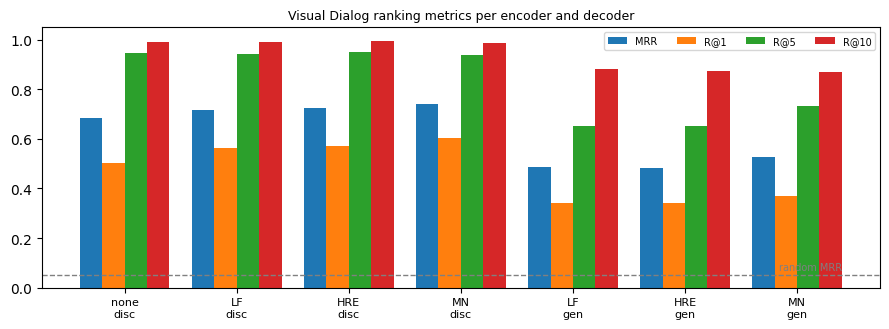

In [34]:
print(f'  {"encoder":8s} {"decoder":8s} {"MRR":>6s} {"R@1":>6s} {"R@5":>6s} {"R@10":>6s} {"mean rank":>10s} {"MRR(it)":>8s} {"MRR(other)":>10s}')
print(f'  {"random":8s} {"-":8s} {theory_mrr:6.3f} {0.01:6.3f} {0.05:6.3f} {0.10:6.3f} {theory_rank:10.2f}')
for key in [('none', 'disc'), ('LF', 'disc'), ('HRE', 'disc'), ('MN', 'disc'), ('LF', 'gen'), ('HRE', 'gen'), ('MN', 'gen')]:
    m = dialog_results[key]
    print(f'  {key[0]:8s} {key[1]:8s} {m["MRR"]:6.3f} {m["R@1"]:6.3f} {m["R@5"]:6.3f} {m["R@10"]:6.3f} '
          f'{m["mean rank"]:10.2f} {m["MRR (it)"]:8.3f} {m["MRR (other)"]:10.3f}')

best_disc = max(['LF', 'HRE', 'MN'], key=lambda e: dialog_results[(e, 'disc')]['MRR'])
best_gen = max(['LF', 'HRE', 'MN'], key=lambda e: dialog_results[(e, 'gen')]['MRR'])
gain_it = dialog_results[(best_disc, 'disc')]['MRR (it)'] - dialog_results[('none', 'disc')]['MRR (it)']
gain_other = dialog_results[(best_disc, 'disc')]['MRR (other)'] - dialog_results[('none', 'disc')]['MRR (other)']
print(f'\n  best discriminative encoder: {best_disc}; best generative encoder: {best_gen}')
print(f'  history gain on "it" questions: {gain_it:+.3f} MRR ({best_disc}-disc vs no history); on other questions: {gain_other:+.3f}')

fig, ax = plt.subplots(figsize=(9, 3.4))
keys = [('none', 'disc'), ('LF', 'disc'), ('HRE', 'disc'), ('MN', 'disc'), ('LF', 'gen'), ('HRE', 'gen'), ('MN', 'gen')]
metrics = ['MRR', 'R@1', 'R@5', 'R@10']
x = np.arange(len(keys)); w = 0.2
for j, mname in enumerate(metrics):
    ax.bar(x + (j - 1.5) * w, [dialog_results[k][mname] for k in keys], w, label=mname)
ax.axhline(theory_mrr, color='gray', ls='--', lw=1); ax.text(6.4, theory_mrr + 0.02, 'random MRR', fontsize=7, color='gray', ha='right')
ax.set_xticks(x); ax.set_xticklabels([f'{e}\n{d}' for e, d in keys], fontsize=8)
ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=4); ax.set_title('Visual Dialog ranking metrics per encoder and decoder', fontsize=9)
plt.tight_layout(); plt.show()

Three things to read off. First, the no-history control is already strong (an MRR close to 0.7), because
the 100 options are built from answers to same-template questions and a question such as "what color is
it" can only have four answers, most of which the image rules out. Second, every history encoder beats
the control, and the gain is concentrated on the "it" questions (MN-disc gains 0.09 MRR there and 0.03 on
the others), which is where the history carries information; the memory network, which can read the one
round that set the referent, is the best of the three. Third, for the same encoder the
**discriminative decoder ranks far better than the generative one** (0.74 against 0.53 MRR for MN), which
is also what the paper's table shows.

Why is the generative decoder so much worse at ranking? Two hypotheses. (a) A **length bias**: it scores
an option by the *summed* log-likelihood of its tokens, which penalises long options, and *nothing* is one
token while *four yellow triangles* is three. (b) An **objective mismatch**: it is trained only to
reproduce the true answer and never to push the 99 distractors down, and many distractors are
near-paraphrases that share most of their tokens with the truth. Hypothesis (a) is testable without
retraining, and Section 10 tests it. Whatever the split, the discriminative decoder is trained
with a softmax over the answer set it is later ranked on (all 129 phrases here, the 100 options in the
paper), and that asymmetry is a large part of why the homework
question, "are there better ways to evaluate Visual Dialog?", is worth asking.

The ranking itself, for one round of one test dialog: the top 10 of the 100 options scored by the best
discriminative model, with the ground truth in green.

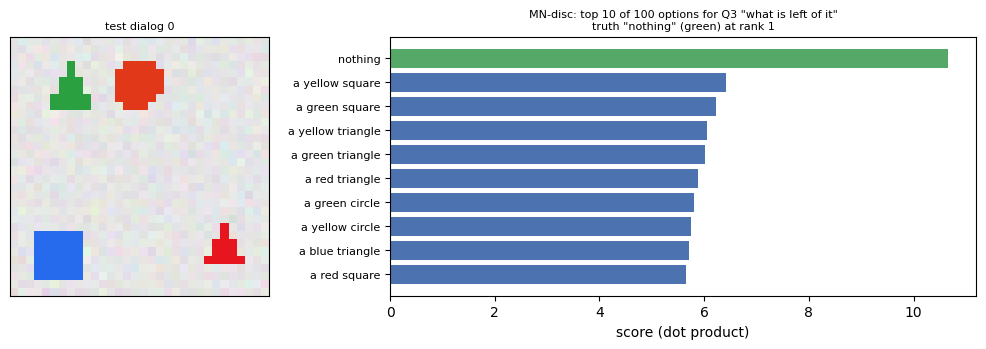

  history Q1: what shape is the green object     A1: it is a triangle
  history Q2: what is below it                   A2: nothing


In [35]:
best_scores = dialog_scores[(best_disc, 'disc')].view(n_te, T_ROUNDS, n_options).detach().cpu().numpy()
best_ranks = gt_rank(dialog_scores[(best_disc, 'disc')], GT_POS.view(-1).to(device)).view(n_te, T_ROUNDS).cpu().numpy()
CAND_NP, GT_NP = CAND.numpy(), GT_POS.numpy()

def draw_ranking(n, t, ax_img, ax_bar, model_name):
    sc = best_scores[n, t]
    top = np.argsort(-sc)[:10]
    labels = [ANS_STR[CAND_NP[n, t, j]] for j in top]
    colors = ['#55A868' if j == GT_NP[n, t] else '#4C72B0' for j in top]
    show_scene(ax_img, vqa_te['images'][n], f'test dialog {n}')
    ax_bar.barh(range(10), sc[top][::-1], color=colors[::-1])
    ax_bar.set_yticks(range(10)); ax_bar.set_yticklabels(labels[::-1], fontsize=8)
    ax_bar.set_xlabel('score (dot product)')
    ax_bar.set_title(f'{model_name}: top 10 of 100 options for Q{t + 1} "{dlg_te["rounds"][n][t][1]}"\n'
                     f'truth "{dlg_te["rounds"][n][t][2]}" (green) at rank {best_ranks[n, t]}', fontsize=8)

n0 = int(next(n for n in range(n_te) if dlg_te['follow'][n, 2]))     # a dialog whose round 3 uses "it"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={'width_ratios': [1, 2.2]})
draw_ranking(n0, 2, ax1, ax2, f'{best_disc}-disc')
plt.tight_layout(); plt.show()
for t in range(2):
    print(f'  history Q{t + 1}: {dlg_te["rounds"][n0][t][1]:34s} A{t + 1}: {dlg_te["rounds"][n0][t][2]}')

### Widget 5: the candidate ranking for one dialog round

Choose a test `dialog` and a `round`. The panel shows the scene, prints the history and the question,
and draws the top 10 options of the best discriminative model with the ground truth marked. The title
reports the rank of the truth. Round 1 has no history, so try a later round whose question contains
"it" and check that the model resolved the referent; then find a round where the truth is not at rank 1
and read off which option the model preferred.

In [36]:
def ranking_widget(dialog=n0, round=3):
    t = round - 1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={'width_ratios': [1, 2.2]})
    draw_ranking(dialog, t, ax1, ax2, f'{best_disc}-disc')
    plt.tight_layout(); plt.show()
    for s in range(t):
        print(f'  history Q{s + 1}: {dlg_te["rounds"][dialog][s][1]:34s} A{s + 1}: {dlg_te["rounds"][dialog][s][2]}')
    if t == 0:
        print('  (no history yet)')

interact(ranking_widget, dialog=IntSlider(min=0, max=n_te - 1, step=1, value=n0, continuous_update=False),
         round=IntSlider(min=1, max=T_ROUNDS, step=1, value=3, continuous_update=False));

interactive(children=(IntSlider(value=0, continuous_update=False, description='dialog', max=399), IntSlider(va…

### Widget 6: encoder and decoder chooser

Pick an `encoder` and a `decoder`; the left panel shows the four ranking metrics, the right panel the MRR
per dialog round. Round 1 has no history, so at round 1 the history encoders have no information the
control lacks (they are separately trained models, so their round-1 MRRs still differ); the separation
should appear from round 2 on. Compare `MN` and `LF` with the same
decoder, then the same encoder with `gen` and `disc`.

In [37]:
def encoder_widget(encoder='MN', decoder='disc'):
    key = (encoder, decoder)
    if key not in dialog_results:
        print('the no-history control was trained with the discriminative decoder only'); return
    m = dialog_results[key]
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
    vals = [m[k] for k in metrics]
    bars = axes[0].bar(metrics, vals, color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'])
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    axes[0].set_ylim(0, 1.1); axes[0].set_title(f'{encoder} + {decoder}: mean rank {m["mean rank"]:.2f}', fontsize=9)
    for k, mm in dialog_results.items():
        axes[1].plot(range(1, T_ROUNDS + 1), mm['per round MRR'], 'o-', lw=2.2 if k == key else 0.8,
                     alpha=1.0 if k == key else 0.35, label=f'{k[0]} {k[1]}')
    axes[1].set_xlabel('dialog round'); axes[1].set_ylabel('MRR'); axes[1].set_xticks(range(1, T_ROUNDS + 1))
    axes[1].legend(fontsize=6.5, ncol=2); axes[1].set_title('MRR per round (round 1 has no history)', fontsize=9)
    plt.tight_layout(); plt.show()

interact(encoder_widget, encoder=Dropdown(options=['none', 'LF', 'HRE', 'MN'], value='MN'),
         decoder=Dropdown(options=['disc', 'gen'], value='disc'));

interactive(children=(Dropdown(description='encoder', index=3, options=('none', 'LF', 'HRE', 'MN'), value='MN'…

## 10. Explore and verify

The checks below re-run the verifications of the notebook in one place with fresh random inputs, confirm
that every trained model beats its floor, and then test the explanation offered in Section 9.d for the
generative decoder: if its ranking suffers from a **length bias**, scoring each option by the *mean*
per-token log-likelihood instead of the sum should help, without retraining anything.

In [38]:
# 1. From-scratch components against their references, once more with fresh random inputs.
set_seed(1)
tok_ = vqa_te['qtok'][:64].to(device)
assert torch.allclose(bow(tok_), bag(tok_), atol=1e-5)
v_, u_ = torch.randn(2, 64, H, device=device), torch.randn(2, H, device=device)
assert torch.allclose(san.layers[0](v_, u_)[0], san_layer_loop(san.layers[0], v_, u_)[0], atol=1e-5)
x_ = torch.randn(3, L_Q, H, device=device)
for k, c in zip((1, 2, 3), hie.qh.convs):
    assert torch.allclose(phrase_conv_scratch(x_, c.weight, c.bias, k),
                          F.conv1d(F.pad(x_.transpose(1, 2), (0, k - 1)), c.weight, c.bias).transpose(1, 2), atol=1e-5)
Q_, V_ = torch.randn(1, L_Q, H, device=device), torch.randn(1, 64, H, device=device)
C_loop = torch.stack([torch.stack([torch.tanh(Q_[0, t] @ hie.coatt[0].W_b @ V_[0, r]) for r in range(64)]) for t in range(L_Q)])
assert torch.allclose(hie.coatt[0].affinity(Q_, V_)[0], C_loop, atol=1e-5)
sc_ = torch.randn(20, 100); gt_ = torch.randint(0, 100, (20,))
assert all(int(gt_rank(sc_, gt_)[n]) == sorted(range(100), key=lambda j: -sc_[n, j].item()).index(int(gt_[n])) + 1 for n in range(20))
print('bag of words, SAN layer, phrase convolution, co-attention affinity and ranking all re-verified. OK')

# 2. Every trained model beats its floor.
for name in ('iBOWIMG', 'LSTM + image', 'SAN', 'HieCoAtt'):
    assert results[name]['overall'] > results['prior (no image)']['overall'], name
for key, m in dialog_results.items():
    assert m['MRR'] > 2 * theory_mrr, key
print('every VQA model beats the no-image prior; every dialog model beats 2x the random MRR. OK')

# 3. The generative decoder's length bias: rescore the same options by the MEAN per-token log-likelihood.
n_tok = (ANS_TOK_BOS[:, 1:] != PAD).sum(1).float()                  # tokens scored per answer string (EOS included)
len_cand = n_tok[CAND.view(-1, n_options).to(device)]
print('\n  generative decoder, summed -> mean per-token log-likelihood:')
for enc in ('LF', 'HRE', 'MN'):
    m_sum = dialog_results[(enc, 'gen')]
    m_mean, _ = evaluate_dialog(dialog_scores[(enc, 'gen')] / len_cand)
    print(f'    {enc:4s} MRR {m_sum["MRR"]:.3f} -> {m_mean["MRR"]:.3f} | R@1 {m_sum["R@1"]:.3f} -> {m_mean["R@1"]:.3f} | '
          f'mean rank {m_sum["mean rank"]:5.2f} -> {m_mean["mean rank"]:5.2f}')

bag of words, SAN layer, phrase convolution, co-attention affinity and ranking all re-verified. OK
every VQA model beats the no-image prior; every dialog model beats 2x the random MRR. OK

  generative decoder, summed -> mean per-token log-likelihood:
    LF   MRR 0.485 -> 0.489 | R@1 0.340 -> 0.345 | mean rank  6.66 ->  6.32
    HRE  MRR 0.484 -> 0.479 | R@1 0.340 -> 0.340 | mean rank  6.56 ->  6.88
    MN   MRR 0.528 -> 0.523 | R@1 0.368 -> 0.368 | mean rank  5.98 ->  6.26


Length normalisation changes the generative MRR by at most 0.005, up for one encoder and down for the
other two. The length-bias hypothesis is rejected: the generative decoder's deficit is the objective
mismatch, not the scoring rule. It was never asked to separate "two green squares" from "two green circles", and a
log-likelihood that differs in one token out of three does not separate them.

### 10.a How much history is enough?

We re-score the best discriminative model with the history truncated to its last $k$ rounds, for $k = 0$
(no history) to $k = 4$ (everything). The synthetic dialogs set a referent and then ask about "it"
possibly several rounds later, so the metric should keep improving with $k$ on the "it" questions. On
the other questions the right comparison is with the no-history *control* of Section 9, not with $k = 0$:
a model trained with history and then shown none is off its training distribution on every round after
the first, so its "other" score at $k = 0$ dips below the control, and it climbs past the control as
rounds are restored because a few non-"it" questions repeat an earlier round word for word and the
history hands over the answer. This is the notebook's small version of the question asked by *History for Visual Dialog: Do
we really need it?* (ACL 2020) in the slide's reading list.

  last 0 round(s) of history: MRR 0.677 | "it" questions 0.768 | other 0.604 | R@1 0.496


  last 1 round(s) of history: MRR 0.710 | "it" questions 0.813 | other 0.628 | R@1 0.550


  last 2 round(s) of history: MRR 0.725 | "it" questions 0.837 | other 0.634 | R@1 0.572


  last 3 round(s) of history: MRR 0.738 | "it" questions 0.855 | other 0.644 | R@1 0.595


  last 4 round(s) of history: MRR 0.742 | "it" questions 0.863 | other 0.645 | R@1 0.603


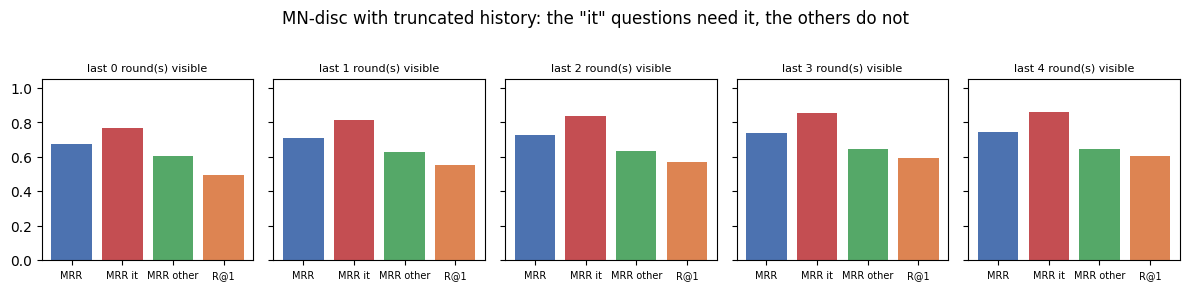

In [39]:
# History truncation sweep on the best discriminative model.
best_model = dialog_models[(best_disc, 'disc')]
trunc = {}
for k in range(T_ROUNDS):
    trunc[k], _ = evaluate_dialog(score_test(best_model, k_hist=k))
    print(f'  last {k} round(s) of history: MRR {trunc[k]["MRR"]:.3f} | "it" questions {trunc[k]["MRR (it)"]:.3f} | '
          f'other {trunc[k]["MRR (other)"]:.3f} | R@1 {trunc[k]["R@1"]:.3f}')
assert trunc[T_ROUNDS - 1]['MRR (it)'] > trunc[0]['MRR (it)'], 'history should help the "it" questions'

fig, axes = plt.subplots(1, T_ROUNDS, figsize=(12, 2.8), sharey=True)
for k, ax in enumerate(axes):
    vals = [trunc[k]['MRR'], trunc[k]['MRR (it)'], trunc[k]['MRR (other)'], trunc[k]['R@1']]
    ax.bar(range(4), vals, color=['#4C72B0', '#C44E52', '#55A868', '#DD8452'])
    ax.set_xticks(range(4)); ax.set_xticklabels(['MRR', 'MRR it', 'MRR other', 'R@1'], fontsize=7)
    ax.set_ylim(0, 1.05); ax.set_title(f'last {k} round(s) visible', fontsize=8)
fig.suptitle(f'{best_disc}-disc with truncated history: the "it" questions need it, the others do not', y=1.02)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

### Widget 7: how many rounds of history?

`k_hist` is the number of most recent rounds the encoder may see. At `k_hist = 0` the model is blind to
the history and the "it" questions fall below the no-history control (0.77 against 0.78 MRR in our run);
each extra round recovers referents set further back, up to 0.86 with everything visible. The right
panel shows the per-round MRR, where the effect of truncation grows with the round number, since later
rounds have more history to lose.

In [40]:
def history_widget(k_hist=T_ROUNDS - 1):
    m = trunc[k_hist]
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
    vals = [m['MRR'], m['MRR (it)'], m['MRR (other)'], m['R@1']]
    bars = axes[0].bar(range(4), vals, color=['#4C72B0', '#C44E52', '#55A868', '#DD8452'])
    for b, v in zip(bars, vals):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    axes[0].set_xticks(range(4)); axes[0].set_xticklabels(['MRR', 'MRR it', 'MRR other', 'R@1'])
    axes[0].set_ylim(0, 1.1); axes[0].set_title(f'last {k_hist} round(s) of history visible', fontsize=9)
    for k in range(T_ROUNDS):
        axes[1].plot(range(1, T_ROUNDS + 1), trunc[k]['per round MRR'], 'o-', lw=2.2 if k == k_hist else 0.8,
                     alpha=1.0 if k == k_hist else 0.3, label=f'k_hist = {k}')
    axes[1].set_xlabel('dialog round'); axes[1].set_ylabel('MRR'); axes[1].set_xticks(range(1, T_ROUNDS + 1))
    axes[1].legend(fontsize=7); axes[1].set_title('MRR per round', fontsize=9)
    plt.tight_layout(); plt.show()

interact(history_widget, k_hist=IntSlider(min=0, max=T_ROUNDS - 1, step=1, value=T_ROUNDS - 1, continuous_update=False));

interactive(children=(IntSlider(value=4, continuous_update=False, description='k_hist', max=4), Output()), _do…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **VQA** | Image + free-form question to answer; posed in practice as classification over the frequent answers (13 here, 1000 in the paper) |
| **Datasets** | VQA (250K images, 750K questions, 10 answers each), COCO-QA (auto-generated from captions, 4 types), Visual7W (7 W's, telling and pointing), CLEVR (rendered, compositional reasoning) |
| **Fusion** | Element-wise product (cheap, symmetric), concatenation (asymmetric), full bilinear (about 1000x the cost, hence compact bilinear pooling) |
| **iBOWIMG** | A bag of words ignores order and still works on questions whose content words determine the answer |
| **SAN** | $\tilde v = \sum_i p_i v_i$, then $u' = \tilde v + u$: attend, add the result back to the query, attend again; the second layer is sharper, but only modestly (3.19 to 2.97 nats) |
| **Co-attention** | Attend to the question as well as the image, at word, phrase and question level, through the affinity $C = \tanh(Q^\top W_b V)$; the learned question attention need not match a human reading |
| **What attention buys** | A pooled global vector loses the binding between attributes and objects; attention restores it (colour and shape go from 0.6 to 1.0); counting stays hard for SAN's normalised attention while co-attention's unnormalised affinity reaches 0.98; no model here beats the prior on relation questions |
| **Visual Dialog** | Image + history + follow-up question to answer; "it" makes the history necessary |
| **Why ranking** | BLEU/METEOR/ROUGE correlate poorly with human judgement, so rank 100 candidates and report mean rank, MRR, R@k; random gives 50.5 and 0.052 |
| **Encoders and decoders** | LF, HRE and MN differ in how they compress the history; the gain from history sits mostly on the "it" questions; discriminative decoders rank far better than generative ones because they are trained on the ranking itself, not because of a length bias |

**Models at a glance**

| Model | Question encoding | Image encoding | Fusion | Attends to |
|---|---|---|---|---|
| LSTM + image | 2-layer LSTM states | one global vector (VGG fc7) | element-wise product | nothing |
| iBOWIMG | bag of words | one global vector | concatenation | nothing |
| SAN | LSTM (or CNN) vector $u$ | grid of region vectors | attention, additive query refinement, 2 layers | image, twice |
| HieCoAtt | word, phrase, question levels | grid of region vectors | parallel co-attention at every level, recursive answer | image and question |
| VisDial LF / HRE / MN | LSTM | one global vector (frozen VGG) | concatenation / dialog LSTM / memory attention | history (HRE, MN) |

## Exercises

1. **The homework from the slides.** *Are there better methods to evaluate Visual Dialog systems? How?*
   The ranking protocol needs a list of 100 options and never scores what a generative model actually
   says, and Section 9.d showed that it rewards the decoder trained on the ranking. The next lecture's
   review slide points to NLP: **consensus metrics** that measure agreement between the generated answer
   and a *set* of relevant answers, as in Massiceti et al., *A Revised Generative Evaluation of Visual
   Dialogue* (arXiv 2020). Write down how you would collect a set of acceptable answers for a round of
   our synthetic dialogs (there is often more than one correct phrasing: "nothing", "no objects") and
   propose a scoring rule that does not need 100 candidates. Then argue why our synthetic data, where
   the answer is unique, hides the problem that motivates such metrics.
2. **Teach the generative decoder to discriminate.** Section 10 showed that length normalisation does not
   close the gap between the generative and discriminative decoders. Add to `GenerativeDecoder.loss` a
   contrastive term: for each training round, the log-likelihood of the true answer minus the
   log-sum-exp of the log-likelihoods of 10 random distractors from `ANS_STR`. Retrain `MN` + `gen` and
   report MRR and R@1 before and after. Then argue what this does to the *generated* answers, which the
   ranking protocol never looks at. *(In our runs the summed and mean per-token scores give MRR 0.528 and
   0.523 for MN-gen against 0.742 for MN-disc; the contrastive term is the reader's experiment.)*
3. **Three hops or one.** Train `lambda: SAN(n_layers=1)` and `lambda: SAN(n_layers=3)` with
   `train_vqa` for the same 1000 steps, and report accuracy per question type together with the mean attention entropy of the last
   layer. Does a third hop keep narrowing the focus, and does it help the count questions?
4. **Break the bag of words.** iBOWIMG cannot tell "what color is the object left of the red circle" from
   "what color is the object right of the red circle" apart from the words *left* and *right*, which it
   does see; but it cannot tell "what is left of the red circle" from a question where *red* modifies a
   different noun. Construct a pair of questions with identical bags of words and different answers on the
   same scene, add them to the generator, and measure how iBOWIMG, SAN and HieCoAtt cope.
5. **Which rounds does the memory network read?** `DialogEncoder` returns the memory attention `alpha`
   for the MN encoder. For test rounds whose question contains "it", plot the average attention over the
   history rounds as a function of how far back the referent was set. Does the model attend to the round
   that set the referent, or simply to the most recent one?
6. **Verify the answer count.** The VQA slide states 750K questions, 10 annotators each, and 10M answers,
   and Section 1 reconciled them with the paper's 13 answers per question: 10 collected with the image
   and 3 without it. Check that composition against the dataset's annotation files: count the questions,
   the answers per question in the image-grounded annotations, and the answers in the separate file of
   answers given without the image, and confirm that the total rounds to 10M. Does every question have
   exactly 10 and 3, or do the counts vary?